In [ ]:
!pip install -q trl
!pip install --upgrade -q pyarrow pandas
from google.colab import drive
drive.mount('/content/drive')
import sys
import numpy as np
from tqdm import tqdm
import time
import torch
import torch.nn.functional as F
import json
import requests
from pathlib import Path
import copy

device = "cuda"
sys.path.append('/content/drive/MyDrive/reasoning_from_scratch')
path = "/content/drive/MyDrive/reasoning_from_scratch"
from reasoning_from_scratch.ch03 import extract_final_candidate, grade_answer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 65.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 177.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but y

In [ ]:

import re
from reasoning_from_scratch.ch03 import extract_final_candidate, grade_answer

def reward_rlvr(answer_text, ground_truth):
    reward = 0.0

    # ---------------------------------------------------------
    # 1. STRICT FORMATTING REWARD (+0.1)
    # ---------------------------------------------------------
    start_idx = answer_text.find("<think>")
    end_idx = answer_text.find("</think>")

    # Rule A: Both tags must exist, and <think> MUST come before </think>
    if start_idx != -1 and end_idx != -1 and start_idx < end_idx:

        # Rule B: There must actually be reasoning inside the tags!
        # (Start index + 7 skips past the actual "<think>" characters)
        reasoning_length = end_idx - (start_idx + 7)

        # Require at least 15 characters of "thinking" to get the reward
        if reasoning_length > 15:
            reward += 0.1

    # ---------------------------------------------------------
    # 2. STRICT MATH REWARD (+1.0)
    # ---------------------------------------------------------
    extracted = extract_final_candidate(
        answer_text, fallback=None
    )

    if not extracted:
        return float(reward)

    # Optional Rule C: You could check if \boxed{} is AFTER </think> here,
    # but for now, let's just make sure the math is right.
    correct = grade_answer(extracted, ground_truth)

    if correct:
        reward += 1.0

    return float(reward)
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen3-0.6B-Base"

# load the tokenizer and the model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    attn_implementation="sdpa", # <--- This is the built-in PyTorch way
    torch_dtype="auto",
    device_map="auto"
)
import json
import requests
from pathlib import Path

def load_math_train(local_path="math_train.json", save_copy=True):
    local_path = Path(local_path)

    url = (
        "https://raw.githubusercontent.com/rasbt/"
        "math_full_minus_math500/refs/heads/main/"
        "math_full_minus_math500.json"
    )
    backup_url = (
        "https://f001.backblazeb2.com/file/reasoning-from-scratch/"
        "MATH/math_full_minus_math500.json"
    )

    if local_path.exists():
        with local_path.open("r", encoding="utf-8") as f:
            data = json.load(f)
    else:
        try:
            r = requests.get(url, timeout=30)
            r.raise_for_status()
        except requests.RequestException:
            print("Using backup URL.")
            r = requests.get(backup_url, timeout=30)
            r.raise_for_status()

        data = r.json()

        if save_copy:
            with local_path.open("w", encoding="utf-8") as f:
                json.dump(data, f, indent=2)

    return data
tokenizer.add_tokens(["<|padding|>"])
tokenizer.pad_token = "<|padding|>"
num_added_toks = tokenizer.add_special_tokens({'additional_special_tokens': ['<|padding|>']})

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

In [ ]:
from datasets import load_dataset, splits

In [ ]:
numina_math = load_dataset("AI-MO/NuminaMath-CoT", split="train[:12000]")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00005.parquet:   0%|          | 0.00/247M [00:00<?, ?B/s]

data/train-00001-of-00005.parquet:   0%|          | 0.00/247M [00:00<?, ?B/s]

data/train-00002-of-00005.parquet:   0%|          | 0.00/247M [00:00<?, ?B/s]

data/train-00003-of-00005.parquet:   0%|          | 0.00/247M [00:00<?, ?B/s]

data/train-00004-of-00005.parquet:   0%|          | 0.00/247M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/166k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/859494 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]

In [ ]:
def refine_prompt(example):
    # We explicitly tell the model the exact tags to use to get the reward
    system_instruction = (
        "Solve the following math problem. You must reason step-by-step. "
        "Put your entire reasoning process inside <think> and </think> tags. "
        "When you are done reasoning, output your final answer inside a \\boxed{} tag.\n\n"
    )

    return system_instruction + "Problem:\n" + example

In [ ]:
import torch
from reasoning_from_scratch.ch03 import extract_final_candidate, grade_answer

# 1. Define our test suite
test_cases = [
    {"problem": "If I have 7 apples and buy 5 more, then give 3 to my friend, how many apples do I have left?", "truth": "9"},
    {"problem": "Solve for x: 4x - 7 = 17.", "truth": "6"},
    {"problem": "A train travels at 60 miles per hour. How many miles does it travel in 2.5 hours?", "truth": "150"}
]

# Put your trained model in evaluation mode
model.eval()

print("🚀 Running Inference Tests...\n")

for i, test in enumerate(test_cases):
    print(f"========== TEST CASE {i+1} ==========")
    print(f"Problem: {test['problem']}")
    print(f"Expected Truth: {test['truth']}\n")

    # 2. Format using your system prompt
    prompt = refine_prompt(test['problem'])

    # 3. Tokenize and get the exact input length (for clean masking)
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    input_len = inputs["input_ids"].shape[1]

    # 4. Generate the response
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=300, # Give it plenty of room to think
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            do_sample=True,
            temperature=0.7,
            top_p=0.9
        )

    # 5. Slice off the prompt so we only see the generated answer
    generated_ids = output_ids[0][input_len:]
    generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True)

    print("--- Model Output ---")
    print(generated_text)
    print("--------------------\n")

    # 6. Evaluate against our strict rules
    # Check Formatting Rule (from our new reward function)
    start_idx = generated_text.find("<think>")
    end_idx = generated_text.find("</think>")

    if start_idx != -1 and end_idx != -1 and start_idx < end_idx:
        reasoning_length = end_idx - (start_idx + 7)
        if reasoning_length > 15:
            print("✅ Formatting: PASS (Tags present and reasoning > 15 chars)")
        else:
            print("❌ Formatting: FAIL (Tags present, but reasoning block is too empty!)")
    else:
        print("❌ Formatting: FAIL (Missing or out-of-order <think> tags)")

    # Check Math Accuracy
    extracted = extract_final_candidate(generated_text, fallback=None)
    if extracted:
        is_correct = grade_answer(extracted, test['truth'])
        if is_correct:
            print(f"✅ Math: PASS! (Extracted: '{extracted}')")
        else:
            print(f"❌ Math: FAIL! (Extracted: '{extracted}', Expected: '{test['truth']}')")
    else:
        print("❌ Math: FAIL! (Could not find \\boxed{} format)")

    print("\n")

🚀 Running Inference Tests...

========== TEST CASE 1 ==========
Problem: If I have 7 apples and buy 5 more, then give 3 to my friend, how many apples do I have left?
Expected Truth: 9

--- Model Output ---
 Let's solve the problem step by step:

1. **Initial number of apples:**  
   You start with 7 apples.

2. **Buying more apples:**  
   You buy 5 more apples.  
   \( 7 + 5 = 12 \) apples.

3. **Giving apples to your friend:**  
   You give 3 apples to your friend.  
   \( 12 - 3 = 9 \) apples.

**Final Answer:**  
\boxed{9}
--------------------

❌ Formatting: FAIL (Missing or out-of-order <think> tags)
✅ Math: PASS! (Extracted: '9')


========== TEST CASE 2 ==========
Problem: Solve for x: 4x - 7 = 17.
Expected Truth: 6

--- Model Output ---
 To solve for x in the equation \(4x - 7 = 17\), we will follow a step-by-step approach:

1. **Start with the given equation:**
   \[
   4x - 7 = 17
   \]

2. **Isolate the term with \(x\):** To do this, we need to get rid of the \(-7\) on the l

In [ ]:
def format_for_completion_loss(example):
    # Adjust this split logic to match whatever your actual separator is
    prompt = refine_prompt(example["problem"])

    return {
        "prompt": prompt + "\n", ### Assistant:", # Everything up to and including the tag
        "completion": "Let me think step by step: \n" + example["solution"]
    }
# 2. Define a function that computes the new data
def add_answer(example):
    # We create a new key called "text_length"
    return {"answer": extract_final_candidate(
        example["solution"], fallback=None  # Require \boxed{}
    )}
numina_math = numina_math.map(format_for_completion_loss)
# 3. Apply the function across the dataset
numina_math = numina_math.map(add_answer)


Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

In [ ]:
numina_math_dataset = numina_math.map(format_for_completion_loss)

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

In [ ]:
tokens = tokenizer(numina_math_dataset[:64]["prompt"], return_tensors="pt", padding_side="left", padding = True)



In [ ]:
from datasets import load_dataset
dataset_id = "math-ai/math500"

# Load the dataset (using 'test' split as math500 is typically a test set)
test_dataset = load_dataset(dataset_id, split="test")

README.md:   0%|          | 0.00/412 [00:00<?, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating test split:   0%|          | 0/500 [00:00<?, ? examples/s]

In [ ]:
test_dataset = test_dataset.map(format_for_completion_loss)


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [ ]:
test_dataset

Dataset({
    features: ['problem', 'solution', 'answer', 'subject', 'level', 'unique_id', 'prompt', 'completion'],
    num_rows: 500
})

In [ ]:


def math_500_accuracy():
  results = []
  bs = 128
  for i in tqdm(range(0, 500, bs)):
    tokens = tokenizer(test_dataset[i:i+bs]["prompt"], return_tensors="pt", padding_side="left", padding = True)
    input_ids, attention_mask = tokens["input_ids"].to(device), tokens["attention_mask"].to(device)
    output_ids = model.generate(inputs=input_ids, attention_mask = attention_mask, max_new_tokens=784-len(tokens[0]), pad_token_id=151643,
    do_sample=True,
    temperature=0.7,
    top_p=0.9)
    generated_strings = tokenizer.batch_decode(
    output_ids,
    skip_special_tokens=True, # Strips out the [PAD], [BOS], [EOS] tokens
    clean_up_tokenization_spaces=True # Fixes weird spacing around punctuation

      )
    print(generated_strings[0])
    for j, label in enumerate(test_dataset[i:i+bs]["answer"]):
      results.append(reward_rlvr(generated_strings[j], label))

    return (sum(results) / len(results)) * 100


In [ ]:
tokens = tokenizer(test_dataset[0:4]["prompt"], return_tensors="pt", padding_side="left", padding = True)
input_ids, attention_mask = tokens["input_ids"].to(device), tokens["attention_mask"].to(device)
output_ids = model.generate(inputs=input_ids, attention_mask = attention_mask, max_new_tokens=784-len(tokens[0]), pad_token_id=151643,
    do_sample=True,
    temperature=0.7,
    top_p=0.9, num_return_sequences=4)
generated_strings = tokenizer.batch_decode(
output_ids,
skip_special_tokens=True, # Strips out the [PAD], [BOS], [EOS] tokens
clean_up_tokenization_spaces=True,
  )

In [ ]:
print(generated_strings)

["Think step by step and solve the problem and write the final result on a new line as:\nConvert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\\theta),$ where $r > 0$ and $0 \\le \\theta < 2 \\pi.$\nTo convert the point \\((0, 3)\\) from rectangular coordinates to polar coordinates, we'll follow these steps:\n\n1. **Identify the Rectangular Coordinates:**\n   - \\( x = 0 \\)\n   - \\( y = 3 \\)\n\n2. **Calculate the Radius \\( r \\):**\n   \n   The radius \\( r \\) is the distance from the origin to the point. It is calculated using the distance formula:\n   \\[\n   r = \\sqrt{x^2 + y^2}\n   \\]\n   \n   Substituting the given values:\n   \\[\n   r = \\sqrt{0^2 + 3^2} = \\sqrt{0 + 9} = \\sqrt{9} = 3\n   \\]\n   \n   Since \\( r > 0 \\), we take the positive value.\n\n3. **Determine the Angle \\( \\theta \\):**\n   \n   The angle \\( \\theta \\) is the angle formed with the positive \\( x \\)-axis. We can find \\( \\theta \\) usin

In [ ]:
print("Accuracy: ", math_500_accuracy())

  0%|          | 0/4 [00:23<?, ?it/s]

Think step by step and solve the problem and write the final result on a new line as:
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
To convert the rectangular coordinates \((0, 3)\) to polar coordinates \((r, \theta)\), follow these steps:

### Step 1: Calculate \(r\)
The radial distance \(r\) is calculated using the formula:
\[
r = \sqrt{x^2 + y^2}
\]
Substitute \(x = 0\) and \(y = 3\):
\[
r = \sqrt{0^2 + 3^2} = \sqrt{9} = 3
\]
So, \(r = 3\).

### Step 2: Calculate \(\theta\)
The angle \(\theta\) is calculated using the formula:
\[
\theta = \arctan\left(\frac{y}{x}\right)
\]
Substitute \(x = 0\) and \(y = 3\):
\[
\theta = \arctan\left(\frac{3}{0}\right)
\]
Since the denominator is 0, the tangent is undefined. This means the angle is undefined in the standard range \([0, 2\pi)\).

However, in polar coordinates, an angle of undefined corresponds to a point on the positive 

In [ ]:
print(generated_strings[-1])

Think step by step and solve the problem and write the final result on a new line as:
How many positive whole-number divisors does 196 have?
To determine the number of positive whole-number divisors of 196, we first need to find its prime factorization. 

1. **Prime Factorization of 196:**
   - Start by dividing 196 by the smallest prime number, which is 2.
   - \(196 \div 2 = 98\)
   - \(98 \div 2 = 49\)
   - 49 is not divisible by 2, so we move to the next smallest prime number, which is 7.
   - \(49 \div 7 = 7\)
   - \(7 \div 7 = 1\)

   Therefore, the prime factorization of 196 is:
   \[
   196 = 2^2 \times 7^2
   \]

2. **Using the Formula for Number of Divisors:**
   If a number \( n \) has a prime factorization of \( p_1^{e_1} \times p_2^{e_2} \times \cdots \times p_k^{e_k} \), then the number of positive divisors of \( n \) is given by:
   \[
   (e_1 + 1)(e_2 + 1) \cdots (e_k + 1)
   \]

   Applying this formula to 196:
   \[
   196 = 2^2 \times 7^2
   \]
   The exponents are 2

In [ ]:
test_dataset = test_dataset.filter(lambda x: len(tokenizer.encode(x["problem"])) < 400)

Filter:   0%|          | 0/496 [00:00<?, ? examples/s]

In [ ]:
sum(results) / len(results)

NameError: name 'results' is not defined

In [ ]:
numina_math = numina_math.filter(lambda x: len(tokenizer.encode(x["prompt"])) < 400)

Filter:   0%|          | 0/12000 [00:00<?, ? examples/s]

In [ ]:
len(numina_math)

In [ ]:
tokenizer.padding_id

In [ ]:
import matplotlib.pyplot as plt

def save_checkpoint(model, checkpoint_dir = ".", step = 50, suffix=""):
    checkpoint_dir = Path(checkpoint_dir)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    suffix = f"-{suffix}" if suffix else ""
    ckpt_path = (
        checkpoint_dir /
        f"qwen3-0.6B-rlvr-grpo-step{step:05d}{suffix}.pth"
    )
    torch.save(model.state_dict(), ckpt_path)
    return ckpt_path

class GRPOTrainer:
  def __init__(self, model, tokenizer, data, optimizer, num_groups, group_size, max_seq_len, device) -> None:
    self.model = model
    self.tokenizer = tokenizer
    self.tokenizer.padding_side = "left"
    self.data = data
    self.optimizer = optimizer
    self.num_groups = num_groups
    self.group_size = group_size
    self.max_seq_len = max_seq_len
    self.device = device
    self.adv_stds = []
    self.rewards = []
    self.accuarcy = []
    self.losses = []
    self.beta = 0.01
    self.current_step = 1
    print("Initializing Old Model...")
    self.old_model = copy.deepcopy(self.model).to(device)
    self.old_model.eval()
    for p in self.old_model.parameters():
        p.requires_grad = False
    print("Initializing Reference Model...")
    self.ref_model = copy.deepcopy(self.model).to(device)
    self.ref_model.eval()
    for p in self.ref_model.parameters():
        p.requires_grad = False
  def figure_results(self):

    # 2. Create a figure and a 2x2 grid of subplots
    # figsize=(width, height) controls the overall size of the window
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))

    # 3. Plot on the Top Left (Row 0, Column 0)
    axs[0, 0].plot(self.adv_stds, color='blue')
    axs[0, 0].set_title('Advantage std')

    # 4. Plot on the Top Right (Row 0, Column 1)
    axs[0, 1].plot(self.rewards, color='red')
    axs[0, 1].set_title('Rewards')

    # 5. Plot on the Bottom Left (Row 1, Column 0)
    axs[1, 0].plot(self.accuarcy, color='green')
    axs[1, 0].set_title('Math-500 accuarcy')

    # 6. Plot on the Bottom Right (Row 1, Column 1)
    axs[1, 1].plot(self.losses, color='purple')
    axs[1, 1].set_title('Training Loss')

    plt.tight_layout()

    plt.show()
  def sequence_logprob(self, logitmodel, generated_indices, prompt_len):
    logits = logitmodel(generated_indices).logits
    logprobs = F.log_softmax(logits, dim = -1)
    target_logprobs = logprobs[:, :-1, :]
    target_indices = generated_indices[:, 1:]
    action_logprobs = torch.gather(target_logprobs,-1, target_indices.unsqueeze(-1)).squeeze_(2)
    eos_mask = (torch.cumsum(generated_indices == self.tokenizer.eos_token_id, dim = 1) > 0)[:, :-1]
    padding_mask = (target_indices == self.tokenizer.pad_token_id)
    start_prompt_ind = padding_mask[0].sum().item()
    prompt_mask = torch.zeros((self.group_size, generated_indices.shape[1]-1), dtype = torch.bool, device = "cuda")
    prompt_mask[:, start_prompt_ind:start_prompt_ind + prompt_len-1] = True
    mask = (prompt_mask | eos_mask) | padding_mask
    action_logprobs.masked_fill_(mask, 0)
    #entropy = (-torch.exp(action_logprobs.float()) * action_logprobs).detach()

    return action_logprobs.sum(1), action_logprobs, (mask == False).sum(dim = 1), (mask == False)
  def get_prompts(self):
    math_prompts = []
    indices = [i.item() for i in np.random.randint(0, 11800, self.num_groups)]
    for i in indices:
      math_prompts.append(refine_prompt(self.data[i]["problem"]))
    answers = [self.data[i]["answer"] for i in indices]
    prompt_lenghts = [len(tokenizer.encode(prompt)) for prompt in math_prompts]
    return math_prompts, answers, prompt_lenghts
  def train(self, num_steps = 500, print_every = 10, checkpoint_every = 50):
    pbar = tqdm(range(self.current_step, num_steps + 1))
    for i in pbar:
      start = time.time()
      stats, response_lenghts = self.train_step()
      end = time.time()
      diff = (end-start)*1000
      tok_per_sec = (self.group_size * self.num_groups * self.max_seq_len) / (end-start)
      pbar.set_postfix(dt=diff, tok_per_sec = str(tok_per_sec), loss = str(stats["loss"]), prompt_lenght = str(response_lenghts))
      self.losses.append(stats["loss"])
      self.adv_stds.append(stats["advantages"].item())
      self.rewards.append(torch.tensor(stats["rewards"]).mean().item())
      if i % print_every == 0:
        reward_avg = torch.tensor(stats["rewards"]).mean().item()
        accuarcy = math_500_accuracy()
        self.accuarcy.append(accuarcy)

        print("MATH 500 Accuracy: ", accuarcy, "%")
        trainer.figure_results()
      if (i) % checkpoint_every == 0:
        ckpt_path = save_checkpoint(
        model=model,
        step=i,
       )
        if i % 200 == 0:
          self.ref_model.load_state_dict(self.model.state_dict())

    print(f"Saved checkpoint to {ckpt_path}")
  def train_step(self):
    math_prompts, answers, prompt_lenghts = self.get_prompts()
    tokens = tokenizer(math_prompts, return_tensors="pt", padding_side="left", padding = True)
    input_ids, attention_mask = tokens["input_ids"].to(device), tokens["attention_mask"].to(device)
    output_ids = self.model.generate(inputs=input_ids, attention_mask = attention_mask, max_new_tokens=self.max_seq_len-len(tokens[0]), pad_token_id=151643,
    do_sample=True,
    temperature=1.0,
    top_p=0.9, num_return_sequences=self.group_size)
    generated_strings = tokenizer.batch_decode(
    output_ids,
    skip_special_tokens=True, # Strips out the [PAD], [BOS], [EOS] tokens
    clean_up_tokenization_spaces=True # Fixes weird spacing around punctuation
      )
    response_lenghts = sum([len(tokenizer.encode(response)) for response in generated_strings]) / (self.num_groups * self.group_size)

    # Make copy of model from previous step
    self.old_model.load_state_dict(self.model.state_dict())

    # (Optional) Double check that it stays in eval mode
    self.old_model.eval()
    with torch.no_grad():
      old_token_logp = torch.zeros((self.num_groups * self.group_size, output_ids.shape[1]-1), device="cuda")
      ref_token_logp = torch.zeros_like(old_token_logp)
      end_pos = []
      with torch.autocast(device_type=self.device, dtype=torch.bfloat16):
        for i in range(self.num_groups):
          _, old_tok, _, _ = self.sequence_logprob(self.old_model, output_ids[i*self.group_size:(i+1) * self.group_size], prompt_lenghts[i])
          _, ref_tok, _, _ = self.sequence_logprob(self.ref_model, output_ids[i*self.group_size:(i+1) * self.group_size], prompt_lenghts[i])
          end_pos.append(ref_tok.shape[1])

          ref_token_logp[i*self.group_size:(i+1) * self.group_size] = ref_tok
          old_token_logp[i*self.group_size:(i+1) * self.group_size] = old_tok



    for _ in range(1):
      stats = self.compute_grpo_loss(
                generated_strings, answers, output_ids, old_token_logp, ref_token_logp, end_pos, prompt_lenghts)
      torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
      self.optimizer.step()
    return stats, response_lenghts
  def compute_grpo_loss(self, texts, answers, token_ids, old_token_logp, ref_tok_logp, end_pos, prompt_lenghts = []):
    roll_rewards = []
    roll_logps = []
    total_loss = 0.0
    total_pg_loss = 0.0
    for i in range(self.num_groups):
      for j in range(self.group_size):
        reward = reward_rlvr(texts[i*self.group_size + j], answers[i])
        roll_rewards.append(reward)
    rewards = torch.tensor(roll_rewards, device = self.device).view(self.num_groups, self.group_size)

    advantages = (rewards - rewards.mean(dim = 1, keepdim=True)) / (rewards.std(dim = 1, keepdim=True) + 1e-4)

    adjusted_advantages = []
    optimizer.zero_grad()

    for i in range(self.num_groups):
      with torch.autocast(device_type=self.device, dtype=torch.bfloat16):
    # 1. Use the RAW advantage for clipping calculations
# THE CORRECTED CODE
        new_logps, new_token_logps, num_tokens, mask = self.sequence_logprob(self.model, token_ids[i*self.group_size:(i+1) * self.group_size], prompt_len = prompt_lenghts[i])

        diff = (ref_tok_logp[i*self.group_size:(i+1) * self.group_size] - new_token_logps).clamp(-20, 20)

        # 1. Calculate KL per-token (Do NOT sum and divide!)
        per_token_kl = torch.exp(diff) - diff - 1.0

        # 2. Get the raw advantage for clipping
        adv = advantages[i].unsqueeze(1)

        # 3. Calculate Ratio
        log_ratio = new_token_logps - old_token_logp[i*self.group_size:(i+1) * self.group_size]
        ratio = torch.exp(log_ratio)
        clipped_ratio = torch.clamp(ratio, 1.0 - 0.2, 1.0 + 0.2)

        # 4. PPO-style clipping strictly based on raw advantage
        unclipped = ratio * adv
        clipped = clipped_ratio * adv
        obj = torch.where(
            adv >= 0,
            torch.minimum(unclipped, clipped),
            torch.maximum(unclipped, clipped),
        )

        # 5. Subtract the token-level KL penalty directly from the token-level objective
        obj = obj - self.beta * per_token_kl

        pg_loss = (-obj * mask).sum() / mask.sum() / self.num_groups

      roll_logps.append(new_logps.detach().cpu())
      pg_loss.backward()
      total_loss += pg_loss.item()
      total_pg_loss += pg_loss.item()
    return {
          "loss": total_loss,
          "pg_loss": total_pg_loss,
          "rewards": roll_rewards,
          "advantages": advantages.cpu().std(),
      }

In [ ]:
"""
        new_logps, new_token_logps, num_tokens, mask = self.sequence_logprob(self.model, token_ids[i*self.group_size:(i+1) * self.group_size], prompt_len = prompt_lenghts[i])
        diff = (ref_tok_logp[i*self.group_size:(i+1) * self.group_size] - new_token_logps.detach()).clamp(-20, 20)
        kl_div = (torch.exp(diff) - (diff) - 1.0).sum(1) / num_tokens # (8, 783) -> mean
        adjusted_adv = (advantages[i] - self.beta * kl_div).detach().unsqueeze(1)
        log_ratio = new_token_logps - old_token_logp[i*self.group_size:(i+1) * self.group_size]
        ratio = torch.exp(log_ratio)
        clipped_ratio = torch.clamp(ratio, 1.0 - 0.2, 1.0 + 0.2)
        # PPO-style clipping
        unclipped = ratio * adjusted_adv
        clipped = clipped_ratio * adjusted_adv
        obj = torch.where(
            adjusted_adv >= 0,
            torch.minimum(unclipped, clipped),
            torch.maximum(unclipped, clipped),
        )
        adjusted_advantages.append(adjusted_adv)"""

'     \n        new_logps, new_token_logps, num_tokens, mask = self.sequence_logprob(self.model, token_ids[i*self.group_size:(i+1) * self.group_size], prompt_len = prompt_lenghts[i])\n        diff = (ref_tok_logp[i*self.group_size:(i+1) * self.group_size] - new_token_logps.detach()).clamp(-20, 20)\n        kl_div = (torch.exp(diff) - (diff) - 1.0).sum(1) / num_tokens # (8, 783) -> mean\n        adjusted_adv = (advantages[i] - self.beta * kl_div).detach().unsqueeze(1)\n        log_ratio = new_token_logps - old_token_logp[i*self.group_size:(i+1) * self.group_size]\n        ratio = torch.exp(log_ratio)\n        clipped_ratio = torch.clamp(ratio, 1.0 - 0.2, 1.0 + 0.2)\n        # PPO-style clipping\n        unclipped = ratio * adjusted_adv\n        clipped = clipped_ratio * adjusted_adv\n        obj = torch.where(\n            adjusted_adv >= 0,\n            torch.minimum(unclipped, clipped),\n            torch.maximum(unclipped, clipped),\n        )\n        adjusted_advantages.append(adju

In [ ]:
import torch.optim as optim
optimizer = optim.AdamW(model.parameters(), lr = 1e-6, fused = True)
import torch

# The flag below controls whether to allow TF32 on matmul. This flag defaults to False
# in PyTorch 1.12 and later.
torch.backends.cuda.matmul.allow_tf32 = True

# The flag below controls whether to allow TF32 on cuDNN. This flag defaults to True.
torch.backends.cudnn.allow_tf32 = True

In [ ]:
model = model.compile()

In [ ]:
import json
import requests
from pathlib import Path

def load_math_train(local_path="math_train.json", save_copy=True):
    local_path = Path(local_path)

    url = (
        "https://raw.githubusercontent.com/rasbt/"
        "math_full_minus_math500/refs/heads/main/"
        "math_full_minus_math500.json"
    )
    backup_url = (
        "https://f001.backblazeb2.com/file/reasoning-from-scratch/"
        "MATH/math_full_minus_math500.json"
    )

    if local_path.exists():
        with local_path.open("r", encoding="utf-8") as f:
            data = json.load(f)
    else:
        try:
            r = requests.get(url, timeout=30)
            r.raise_for_status()
        except requests.RequestException:
            print("Using backup URL.")
            r = requests.get(backup_url, timeout=30)
            r.raise_for_status()

        data = r.json()

        if save_copy:
            with local_path.open("w", encoding="utf-8") as f:
                json.dump(data, f, indent=2)

    return data

In [ ]:
data = load_math_train()

In [ ]:
trainer = GRPOTrainer(model, tokenizer, data, optimizer, 4, 8, 1024, "cuda")

Initializing Old Model...
Initializing Reference Model...


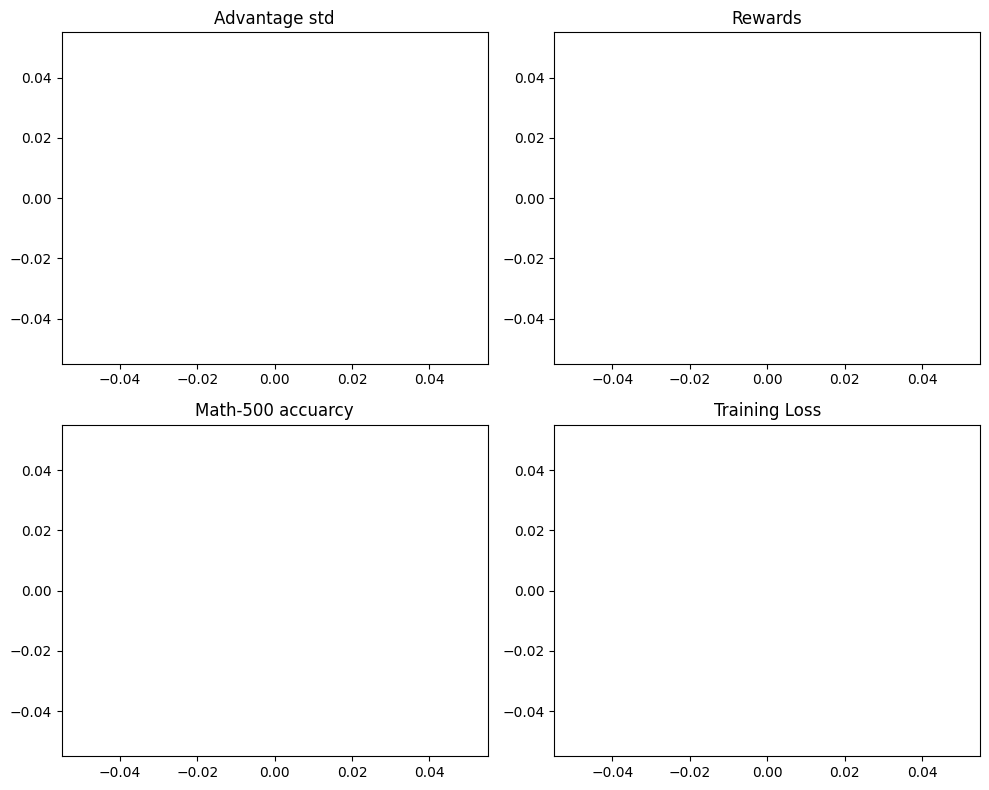

In [ ]:
trainer.figure_results()

TypeError: list indices must be integers or slices, not str

In [ ]:
trainer.beta = 0

  0%|          | 0/4 [00:23<?, ?it/s]

Think step by step and solve the problem and write the final result on a new line as:
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
To convert the point \((0, 3)\) from rectangular coordinates to polar coordinates, follow these steps:

1. **Identify the Rectangular Coordinates:**
   - \( x = 0 \)
   - \( y = 3 \)

2. **Calculate the Radius \( r \):**
   
   The radius \( r \) is the distance from the origin to the point. It can be calculated using the Pythagorean theorem:
   \[
   r = \sqrt{x^2 + y^2}
   \]
   Substituting the given values:
   \[
   r = \sqrt{0^2 + 3^2} = \sqrt{9} = 3
   \]

3. **Determine the Angle \( \theta \):**
   
   The angle \( \theta \) is the angle between the positive \( x \)-axis and the line connecting the origin to the point. It can be found using the arctangent function:
   \[
   \theta = \arctan\left(\frac{y}{x}\right)
   \]
   Substituting

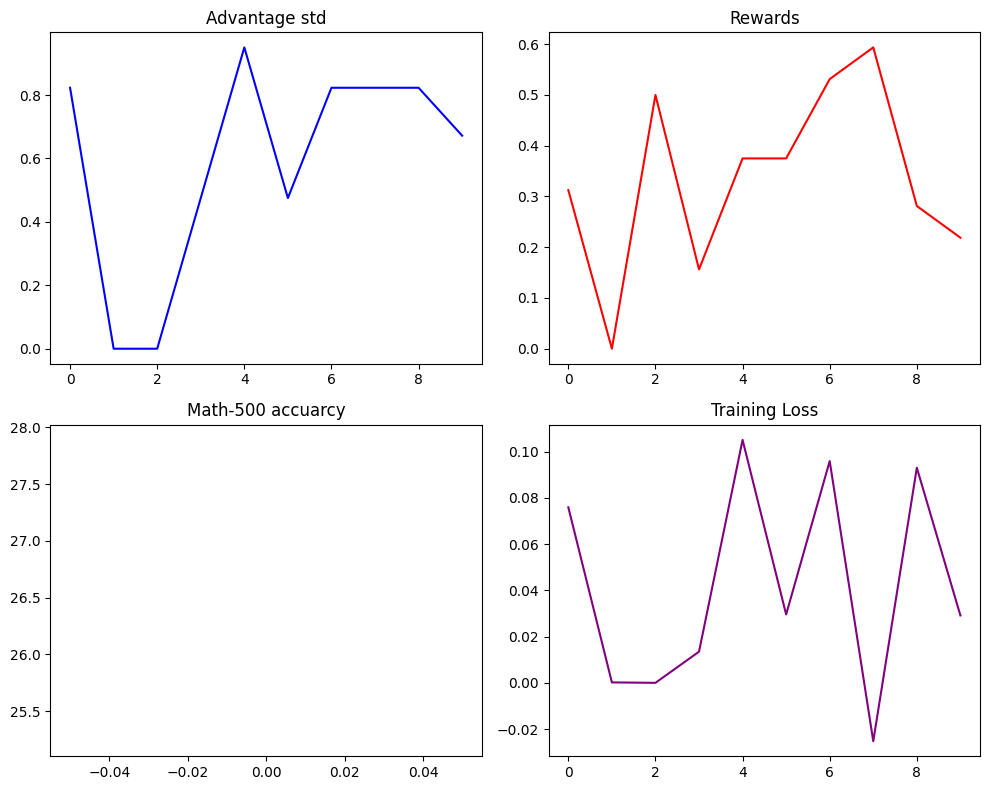

  0%|          | 0/4 [00:23<?, ?it/s]

Think step by step and solve the problem and write the final result on a new line as:
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
To convert the rectangular coordinates \((0, 3)\) to polar coordinates \((r, \theta)\), follow these steps:

1. **Calculate \(r\):**
   
   The radial distance \(r\) is given by the formula:
   \[
   r = \sqrt{x^2 + y^2}
   \]
   
   Substituting the given values \(x = 0\) and \(y = 3\):
   \[
   r = \sqrt{0^2 + 3^2} = \sqrt{9} = 3
   \]

2. **Calculate \(\theta\):**
   
   The angle \(\theta\) is given by the formula:
   \[
   \theta = \arctan\left(\frac{y}{x}\right)
   \]
   
   Substituting the given values \(x = 0\) and \(y = 3\):
   \[
   \theta = \arctan\left(\frac{3}{0}\right)
   \]
   
   The arctangent of \(\frac{3}{0}\) is undefined because the denominator is zero. However, we can consider the principal value:
   
   - When \(x > 0\

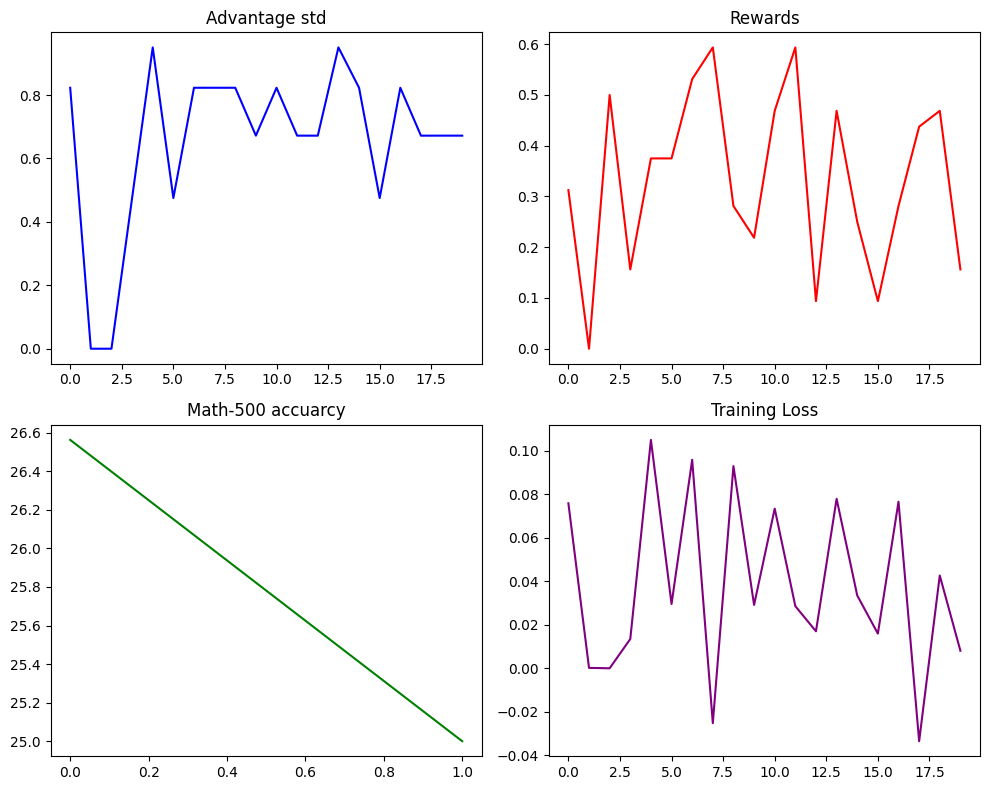

  0%|          | 0/4 [00:23<?, ?it/s]

Think step by step and solve the problem and write the final result on a new line as:
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
To convert the point \((0, 3)\) from rectangular coordinates to polar coordinates, follow these steps:

1. **Identify the Rectangular Coordinates:**
   - \(x = 0\)
   - \(y = 3\)

2. **Calculate the Radius \(r\):**
   
   The radius \(r\) is the distance from the origin to the point, calculated using the Pythagorean theorem:
   \[
   r = \sqrt{x^2 + y^2}
   \]
   Substituting the given values:
   \[
   r = \sqrt{0^2 + 3^2} = \sqrt{0 + 9} = \sqrt{9} = 3
   \]

3. **Determine the Angle \(\theta\):**
   
   The angle \(\theta\) is the angle between the positive \(x\)-axis and the line connecting the origin to the point. Since the point \((0, 3)\) lies on the positive \(y\)-axis, the angle \(\theta\) is:
   \[
   \theta = \frac{\pi}{2} \quad \tex

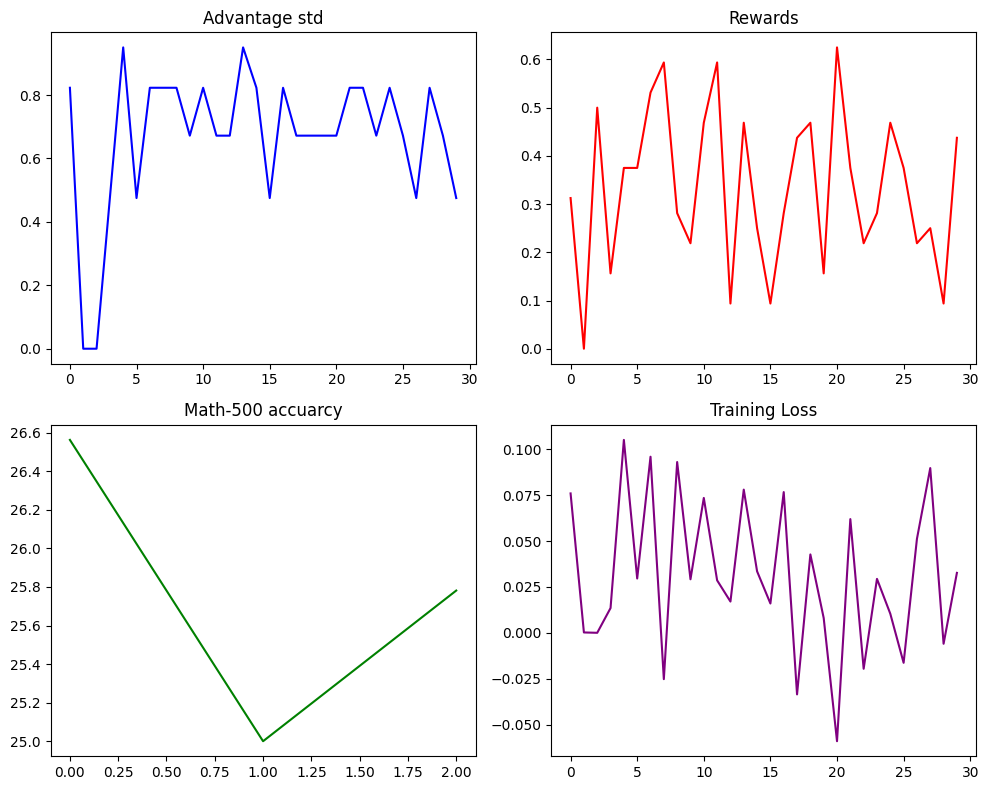

  0%|          | 0/4 [00:23<?, ?it/s]

Think step by step and solve the problem and write the final result on a new line as:
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
To convert the point \((0, 3)\) from rectangular coordinates \((x, y)\) to polar coordinates \((r, \theta)\), follow these steps:

1. **Calculate \(r\) (the radius):**
   
   The formula for \(r\) is:
   \[
   r = \sqrt{x^2 + y^2}
   \]
   
   Substituting the given values \(x = 0\) and \(y = 3\):
   \[
   r = \sqrt{0^2 + 3^2} = \sqrt{9} = 3
   \]

2. **Calculate \(\theta\) (the angle):**
   
   The formula for \(\theta\) is:
   \[
   \theta = \arctan\left(\frac{y}{x}\right)
   \]
   
   Substituting the given values \(x = 0\) and \(y = 3\):
   \[
   \theta = \arctan\left(\frac{3}{0}\right)
   \]
   
   The arctangent of a division by zero is undefined. This means the angle \(\theta\) is undefined. However, since the point \((0, 3)\) lies on 

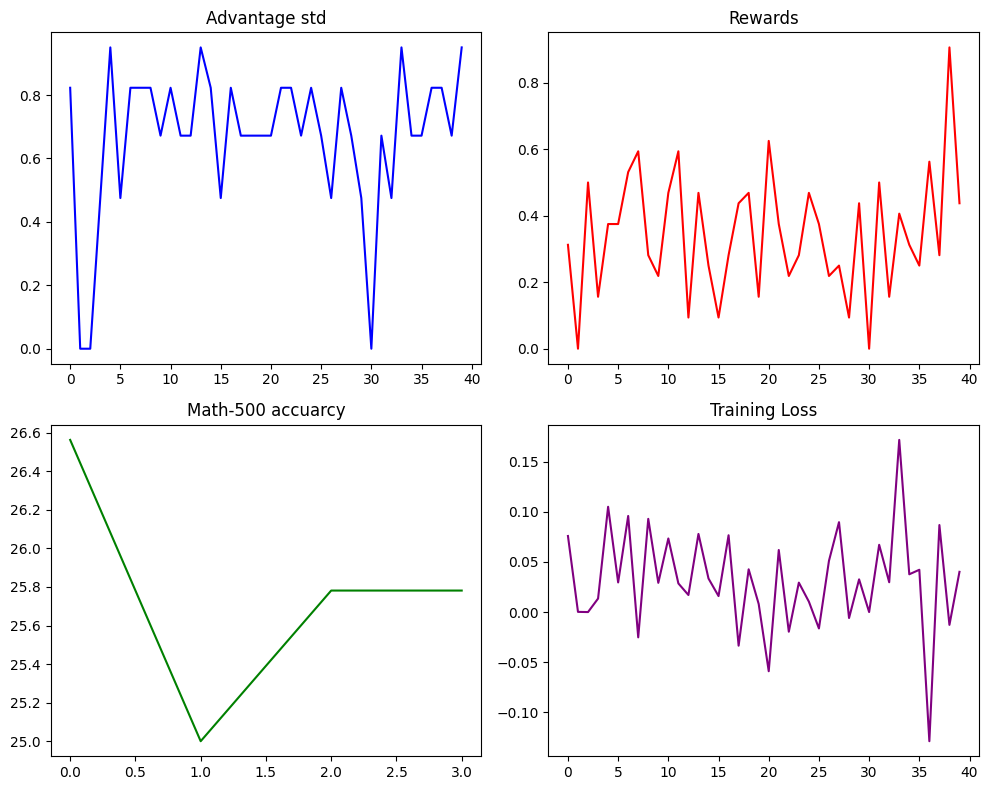

  0%|          | 0/4 [00:23<?, ?it/s]

Think step by step and solve the problem and write the final result on a new line as:
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
To convert the point \((0, 3)\) from rectangular coordinates to polar coordinates, follow these steps:

1. **Identify the rectangular coordinates:**
   \[
   (x, y) = (0, 3)
   \]

2. **Calculate the radial distance \(r\):**
   The radial distance \(r\) is the distance from the origin to the point \((x, y)\). It is calculated using the formula:
   \[
   r = \sqrt{x^2 + y^2}
   \]
   Substituting the given values:
   \[
   r = \sqrt{0^2 + 3^2} = \sqrt{0 + 9} = \sqrt{9} = 3
   \]

3. **Calculate the angle \(\theta\):**
   The angle \(\theta\) is the angle formed with the positive \(x\)-axis. It is calculated using the formula:
   \[
   \theta = \tan^{-1}\left(\frac{y}{x}\right)
   \]
   Substituting the given values:
   \[
   \theta = \tan^{-1}

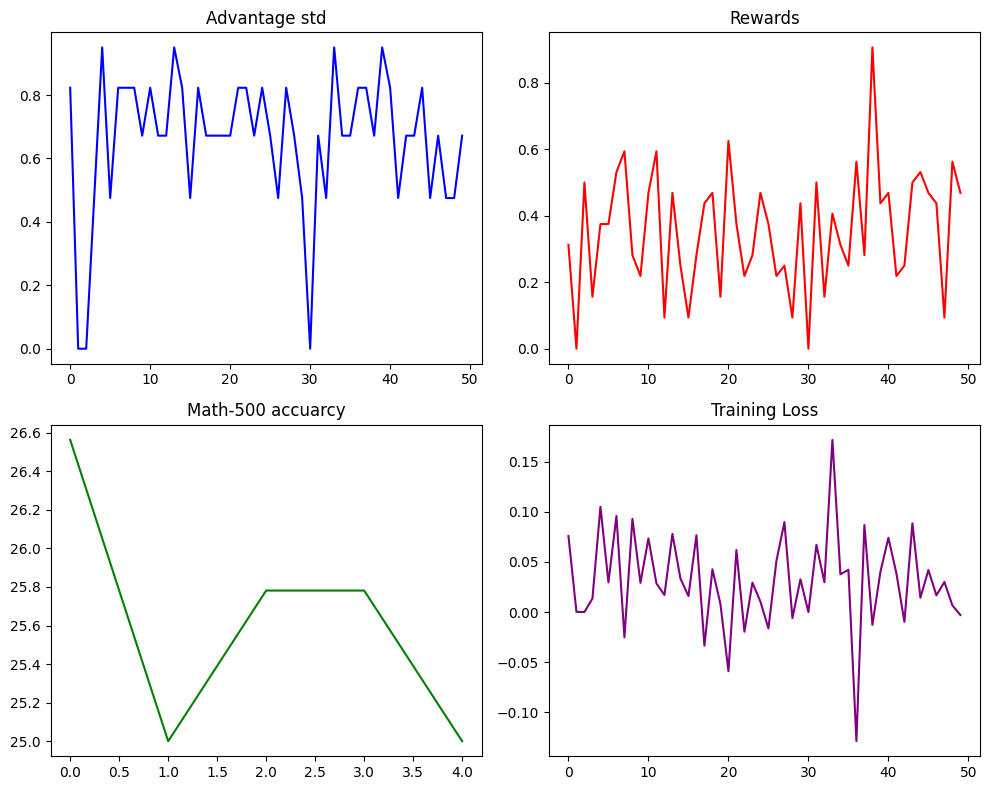

  0%|          | 0/4 [00:23<?, ?it/s]

Think step by step and solve the problem and write the final result on a new line as:
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
To convert the rectangular coordinates \((0, 3)\) to polar coordinates \((r, \theta)\), follow these steps:

1. **Calculate \(r\):**
   
   The formula for converting rectangular coordinates \((x, y)\) to polar coordinates \((r, \theta)\) is:
   \[
   r = \sqrt{x^2 + y^2}
   \]
   
   Plugging in the values:
   \[
   r = \sqrt{0^2 + 3^2} = \sqrt{9} = 3
   \]

2. **Calculate \(\theta\):**
   
   The formula for converting rectangular coordinates to polar coordinates is:
   \[
   \theta = \arctan\left(\frac{y}{x}\right)
   \]
   
   However, we need to consider the quadrant in which the point \((0, 3)\) lies.
   
   - If \(x > 0\) and \(y > 0\), \(\theta = \arctan\left(\frac{3}{0}\right)\) is undefined, so \(\theta = \frac{\pi}{2}\).
   - If \(

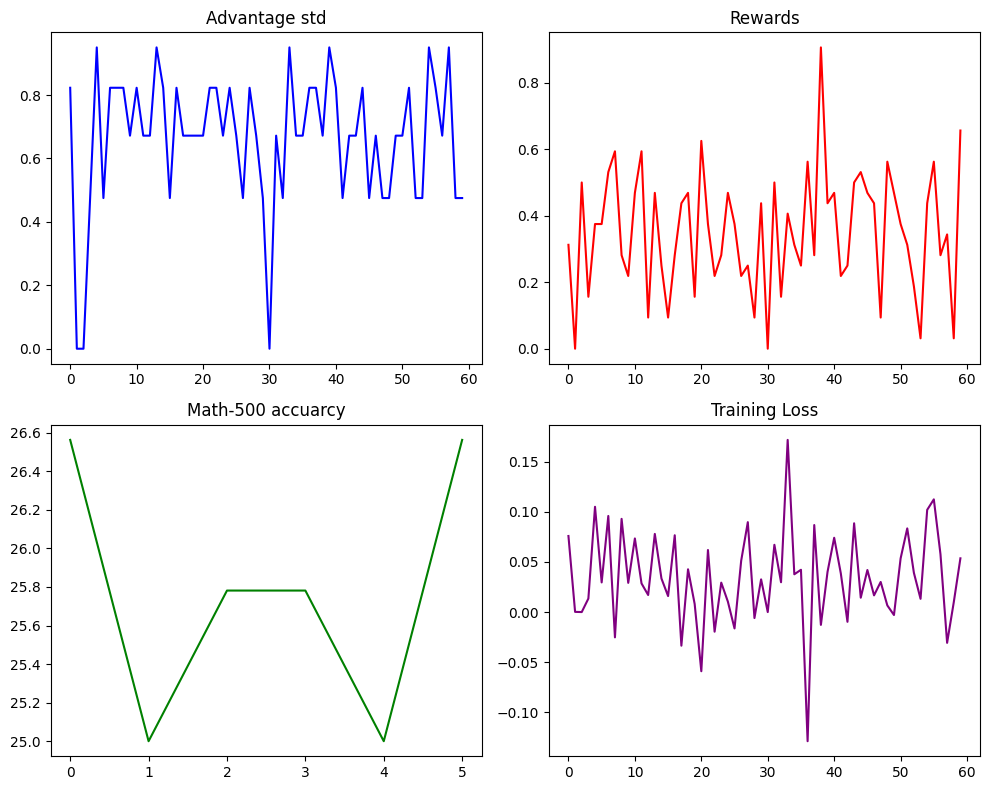

  0%|          | 0/4 [00:23<?, ?it/s]

Think step by step and solve the problem and write the final result on a new line as:
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
To convert the rectangular coordinates \((0, 3)\) to polar coordinates \((r, \theta)\), follow these steps:

1. **Calculate \(r\):**
   
   The radius \(r\) is the distance from the origin to the point. It is calculated using the formula:
   \[
   r = \sqrt{x^2 + y^2}
   \]
   
   Substituting the given values \(x = 0\) and \(y = 3\):
   \[
   r = \sqrt{0^2 + 3^2} = \sqrt{9} = 3
   \]

2. **Calculate \(\theta\):**
   
   The angle \(\theta\) is the angle formed with the positive \(x\)-axis. It is calculated using the formula:
   \[
   \theta = \arctan\left(\frac{y}{x}\right)
   \]
   
   However, we need to consider the quadrant in which the point lies to determine the correct angle.
   
   - Since \(x = 0\) and \(y = 3\), the point \((0, 3)\

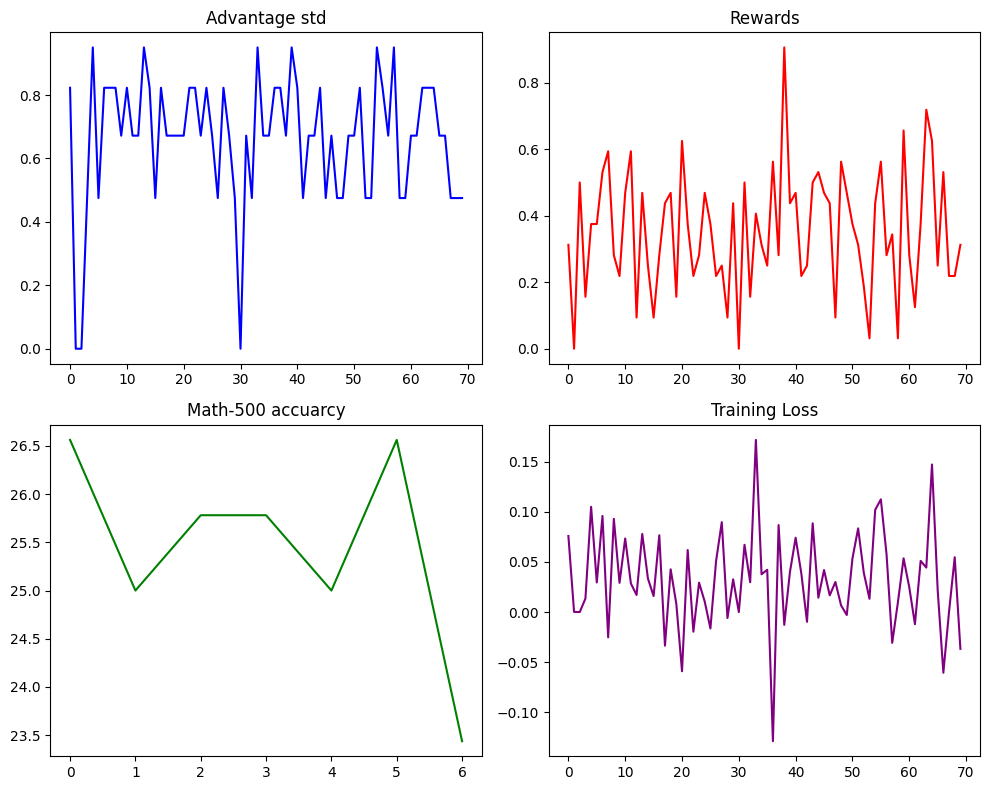

  0%|          | 0/4 [00:23<?, ?it/s]

Think step by step and solve the problem and write the final result on a new line as:
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
To convert the point \((0, 3)\) from rectangular coordinates to polar coordinates, we'll follow these steps:

### Step 1: Identify the Rectangular Coordinates
The given rectangular coordinates are:
\[
(x, y) = (0, 3)
\]
where:
\[
x = 0 \quad \text{and} \quad y = 3
\]

### Step 2: Calculate the Distance \(r\)
The distance \(r\) from the origin to the point is given by the Pythagorean theorem:
\[
r = \sqrt{x^2 + y^2}
\]
Substituting the values of \(x\) and \(y\):
\[
r = \sqrt{0^2 + 3^2} = \sqrt{0 + 9} = \sqrt{9} = 3
\]

### Step 3: Determine the Angle \(\theta\)
The angle \(\theta\) is measured from the positive \(x\)-axis. For the point \((0, 3)\), the angle is:
\[
\theta = \arctan\left(\frac{y}{x}\right)
\]
However, since \(x = 0\) and \(y = 

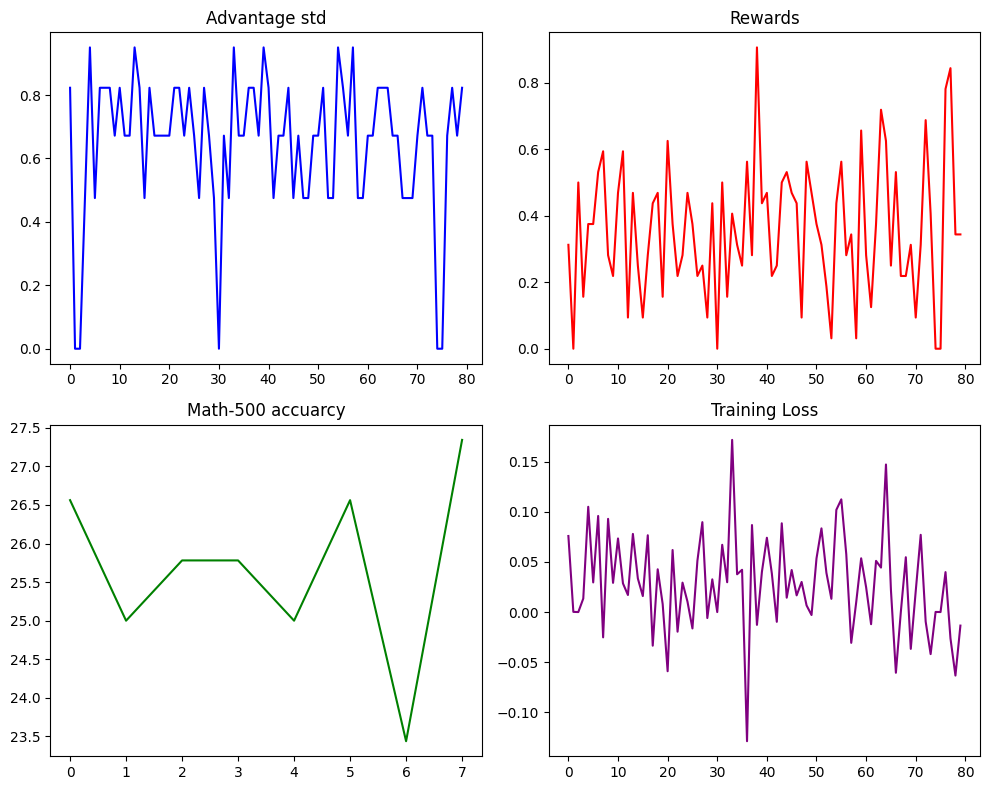

  0%|          | 0/4 [00:23<?, ?it/s]

Think step by step and solve the problem and write the final result on a new line as:
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
To convert the rectangular coordinates \((0, 3)\) to polar coordinates \((r, \theta)\), follow these steps:

### Step 1: Find the radial distance \( r \)
The radial distance \( r \) is calculated using the formula:
\[
r = \sqrt{x^2 + y^2}
\]
Substitute \( x = 0 \) and \( y = 3 \):
\[
r = \sqrt{0^2 + 3^2} = \sqrt{9} = 3
\]

### Step 2: Determine the angle \( \theta \)
The angle \( \theta \) is found using the arctangent function:
\[
\theta = \arctan\left(\frac{y}{x}\right)
\]
Substitute \( x = 0 \) and \( y = 3 \):
\[
\theta = \arctan\left(\frac{3}{0}\right)
\]
Since \( \frac{3}{0} \) is undefined, we need to consider the quadrant in which the point lies.

- If \( x > 0 \) and \( y > 0 \), the point is in the first quadrant.
- If \( x < 0 \) a

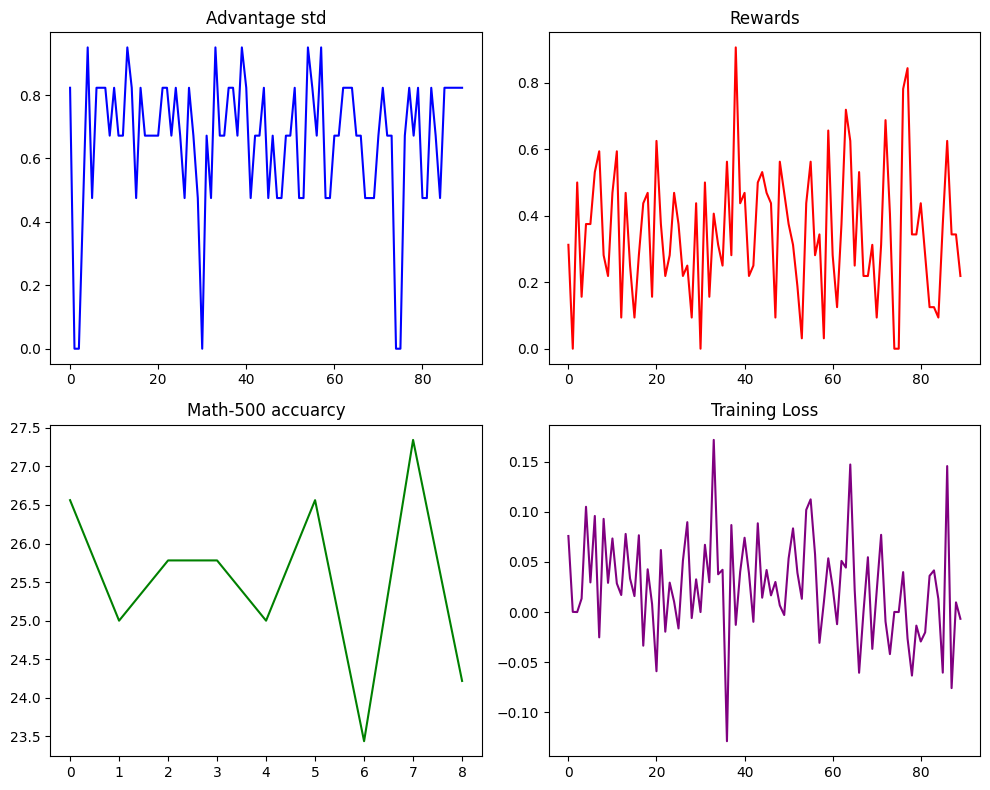

  0%|          | 0/4 [00:23<?, ?it/s]

Think step by step and solve the problem and write the final result on a new line as:
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
To convert the rectangular coordinates \((0, 3)\) to polar coordinates \((r, \theta)\), follow these steps:

1. **Calculate \(r\) (the distance from the origin):**
   
   The formula for \(r\) is:
   \[
   r = \sqrt{x^2 + y^2}
   \]
   
   Substituting the given values \(x = 0\) and \(y = 3\):
   \[
   r = \sqrt{0^2 + 3^2} = \sqrt{9} = 3
   \]
   
2. **Calculate \(\theta\) (the angle from the positive \(x\)-axis):**
   
   The formula for \(\theta\) is:
   \[
   \theta = \arctan\left(\frac{y}{x}\right)
   \]
   
   Substituting the given values \(x = 0\) and \(y = 3\):
   \[
   \theta = \arctan\left(\frac{3}{0}\right)
   \]
   
   The arctangent of a non-zero value is undefined because the \(x\)-coordinate is zero. This means the point lies o

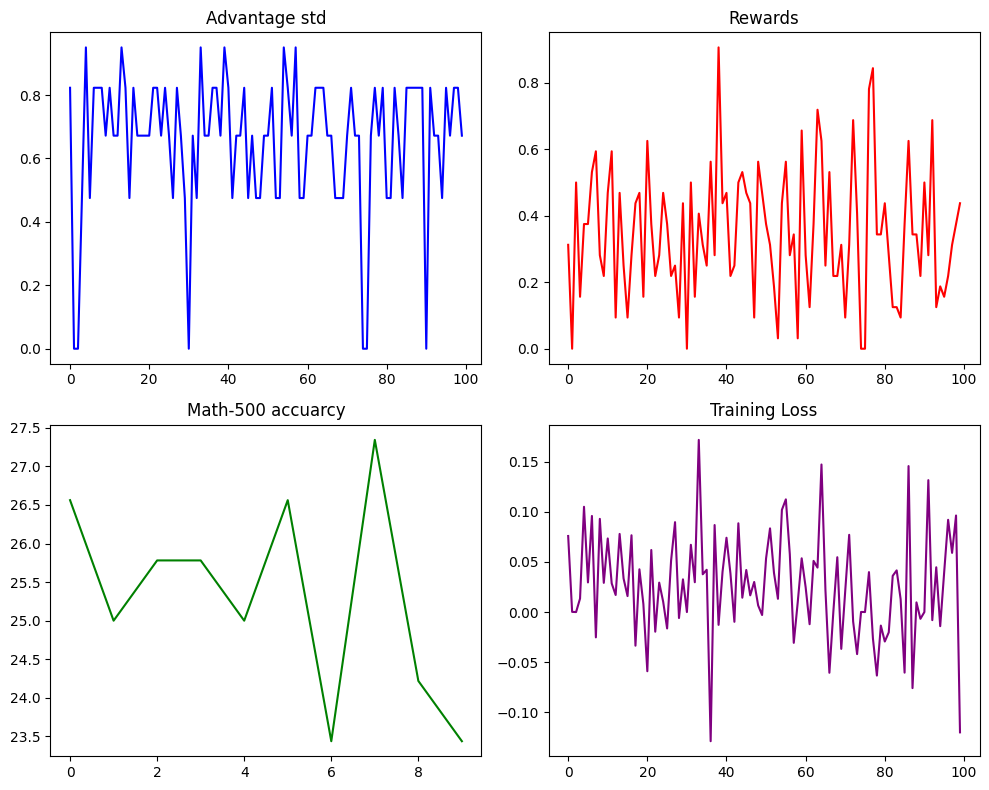

  0%|          | 0/4 [00:23<?, ?it/s]

Think step by step and solve the problem and write the final result on a new line as:
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
To convert the rectangular coordinates \((0, 3)\) to polar coordinates \((r, \theta)\), follow these steps:

### Step 1: Calculate \(r\)
The radius \(r\) is given by the formula:
\[
r = \sqrt{x^2 + y^2}
\]
Substitute \(x = 0\) and \(y = 3\):
\[
r = \sqrt{0^2 + 3^2} = \sqrt{9} = 3
\]

### Step 2: Calculate \(\theta\)
The angle \(\theta\) is given by the formula:
\[
\theta = \arctan\left(\frac{y}{x}\right)
\]
Substitute \(x = 0\) and \(y = 3\):
\[
\theta = \arctan\left(\frac{3}{0}\right)
\]
Since \(\arctan\left(\frac{3}{0}\right)\) is undefined, we need to consider the quadrant in which the point lies.

- If \(x > 0\) and \(y > 0\), \(\theta\) is in the **first quadrant**:
  \[
  \theta = \arctan(1) = \frac{\pi}{4}
  \]
- If \(x < 0\) and \(y >

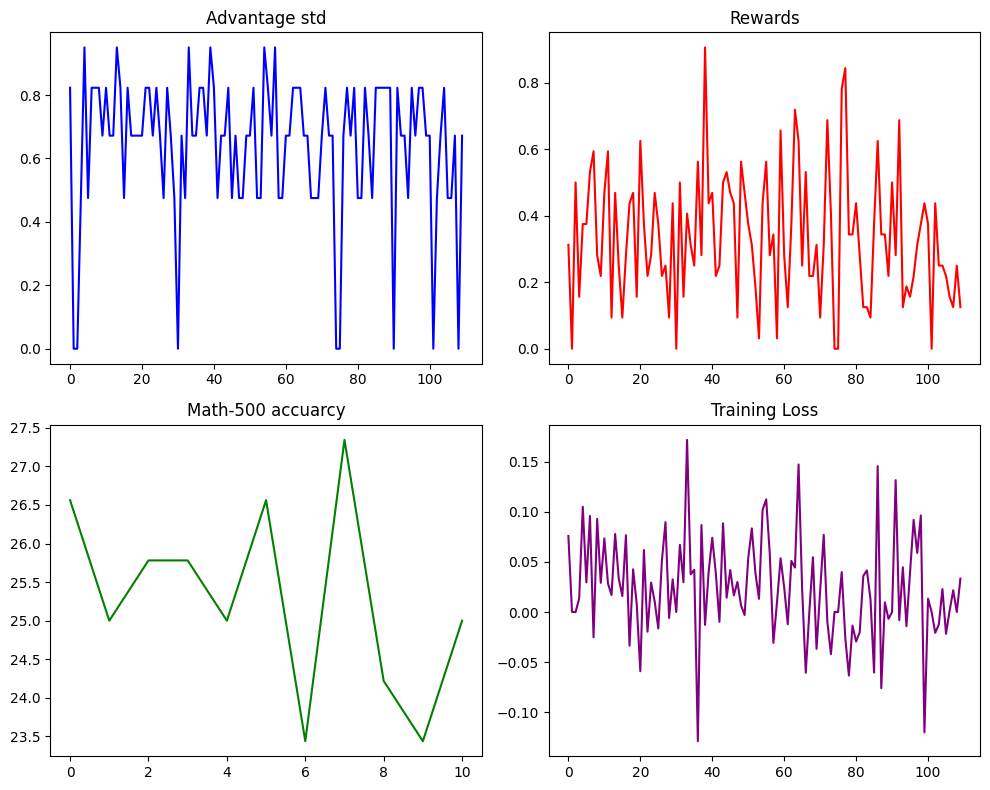

  0%|          | 0/4 [00:23<?, ?it/s]

Think step by step and solve the problem and write the final result on a new line as:
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
To convert the rectangular coordinates \((0, 3)\) to polar coordinates \((r, \theta)\), follow these steps:

1. **Calculate \(r\) (the distance from the origin):**
   
   The formula for \(r\) is:
   \[
   r = \sqrt{x^2 + y^2}
   \]
   
   Substituting the given values \(x = 0\) and \(y = 3\):
   \[
   r = \sqrt{0^2 + 3^2} = \sqrt{9} = 3
   \]

2. **Determine \(\theta\) (the angle with the positive \(x\)-axis):**
   
   The angle \(\theta\) can be found using the arctangent function:
   \[
   \theta = \arctan\left(\frac{y}{x}\right)
   \]
   
   Substituting \(x = 0\) and \(y = 3\):
   \[
   \theta = \arctan\left(\frac{3}{0}\right)
   \]
   
   The tangent of 0 is 0, and the tangent of \(\frac{\pi}{2}\) is undefined. Therefore:
   \[
   \thet

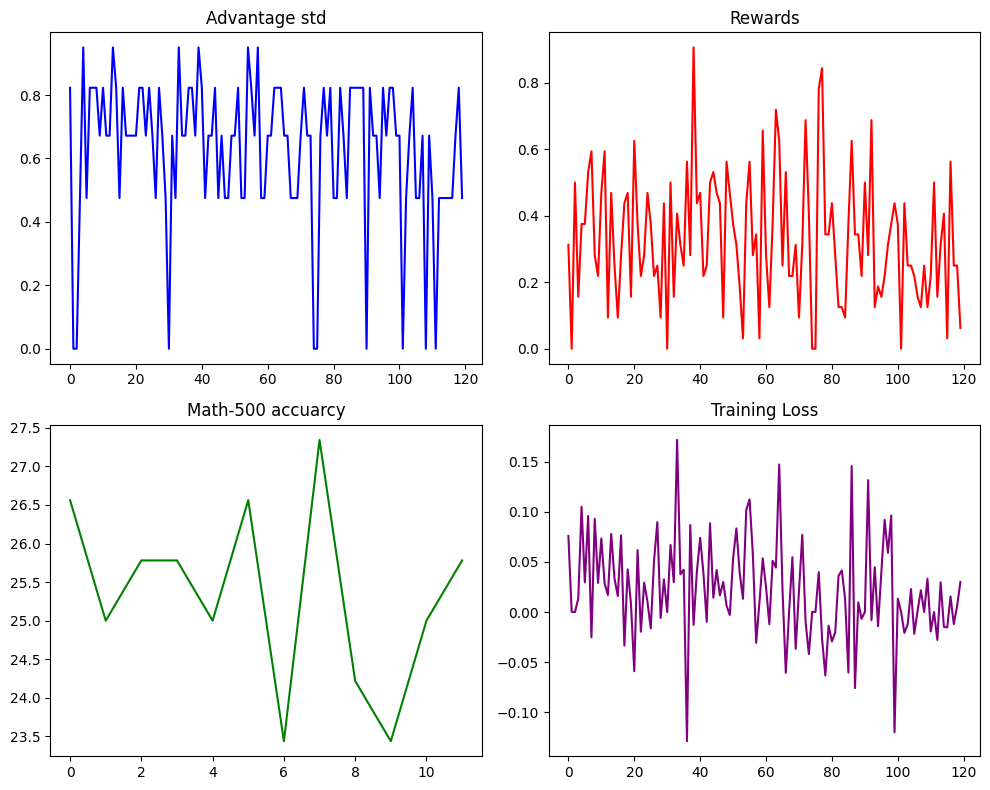

  0%|          | 0/4 [00:23<?, ?it/s]

Think step by step and solve the problem and write the final result on a new line as:
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
To convert the rectangular coordinates \((0, 3)\) to polar coordinates \((r, \theta)\), follow these steps:

1. **Calculate \(r\) (the distance from the origin):**
   
   The formula for \(r\) is:
   \[
   r = \sqrt{x^2 + y^2}
   \]
   
   Substituting the given coordinates \((0, 3)\):
   \[
   r = \sqrt{0^2 + 3^2} = \sqrt{9} = 3
   \]

2. **Determine \(\theta\) (the angle with the positive \(x\)-axis):**
   
   The angle \(\theta\) can be found using the arctangent function:
   \[
   \theta = \arctan\left(\frac{y}{x}\right)
   \]
   
   Substituting the given coordinates:
   \[
   \theta = \arctan\left(\frac{3}{0}\right)
   \]
   
   The tangent of 90 degrees is undefined, which means the angle is \(\frac{\pi}{2}\) radians (or 90 degrees).
 

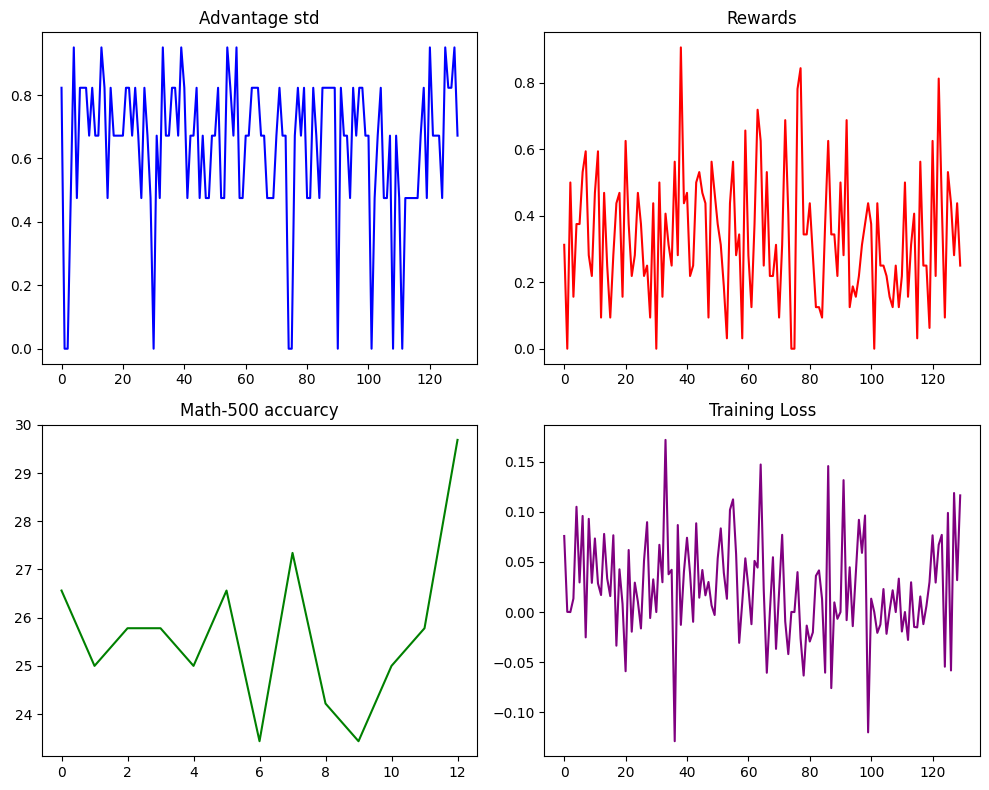

  0%|          | 0/4 [00:23<?, ?it/s]

Think step by step and solve the problem and write the final result on a new line as:
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
To convert the point \((0, 3)\) from rectangular (Cartesian) coordinates to polar coordinates, we'll follow these steps:

### Step 1: Identify the Rectangular Coordinates
The given point is \((x, y) = (0, 3)\).

### Step 2: Calculate the Radius \(r\)
The radius \(r\) is the distance from the origin to the point. It is calculated using the distance formula:
\[
r = \sqrt{x^2 + y^2}
\]
Substituting the values of \(x\) and \(y\):
\[
r = \sqrt{0^2 + 3^2} = \sqrt{9} = 3
\]
Since \(r\) is positive and \(r > 0\), we have:
\[
r = 3
\]

### Step 3: Calculate the Angle \(\theta\)
The angle \(\theta\) is the angle between the positive \(x\)-axis and the line connecting the origin to the point. It is calculated using the arctangent function:
\[
\theta = \

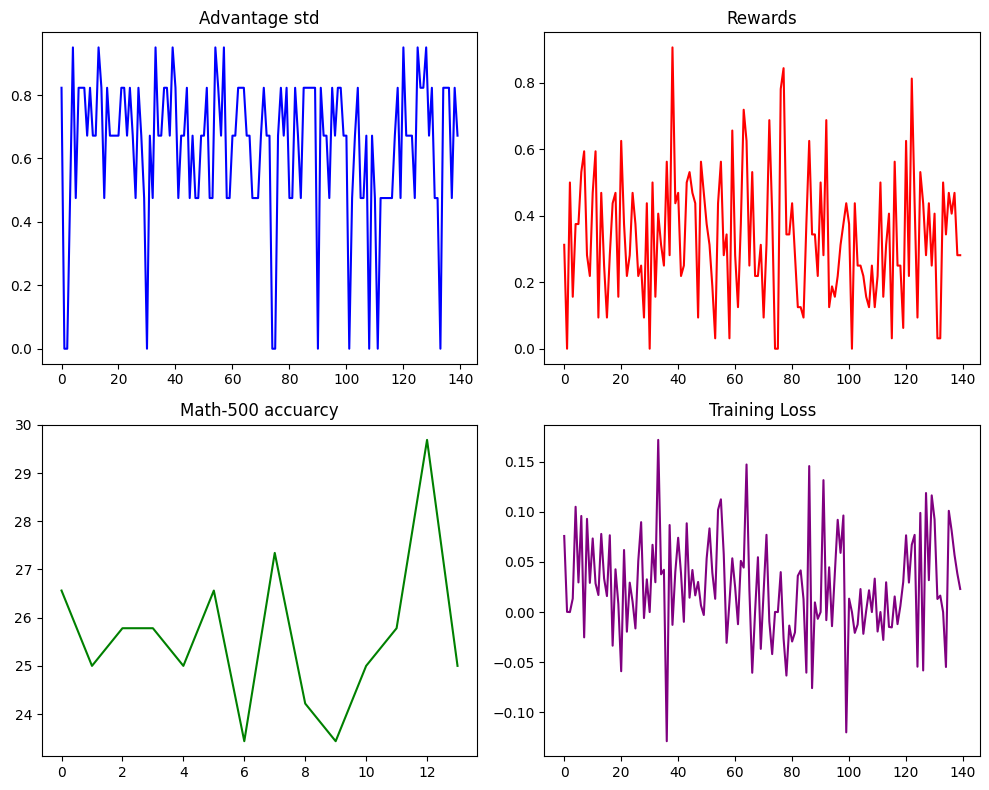

  0%|          | 0/4 [00:23<?, ?it/s]

Think step by step and solve the problem and write the final result on a new line as:
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
To convert the point \((0, 3)\) from rectangular coordinates \((x, y)\) to polar coordinates \((r, \theta)\), follow these steps:

### Step 1: Calculate \(r\)
The radial distance \(r\) is given by the formula:
\[
r = \sqrt{x^2 + y^2}
\]
Substitute \(x = 0\) and \(y = 3\):
\[
r = \sqrt{0^2 + 3^2} = \sqrt{9} = 3
\]
So, \(r = 3\).

### Step 2: Calculate \(\theta\)
The angle \(\theta\) is determined using the arctangent function:
\[
\theta = \arctan\left(\frac{y}{x}\right)
\]
Substitute \(x = 0\) and \(y = 3\):
\[
\theta = \arctan\left(\frac{3}{0}\right)
\]
Since the \(x\)-coordinate is 0 and the \(y\)-coordinate is 3, the point lies on the positive \(y\)-axis. The angle in this case is:
\[
\theta = \frac{\pi}{2}
\]

### Final Answer
The polar co

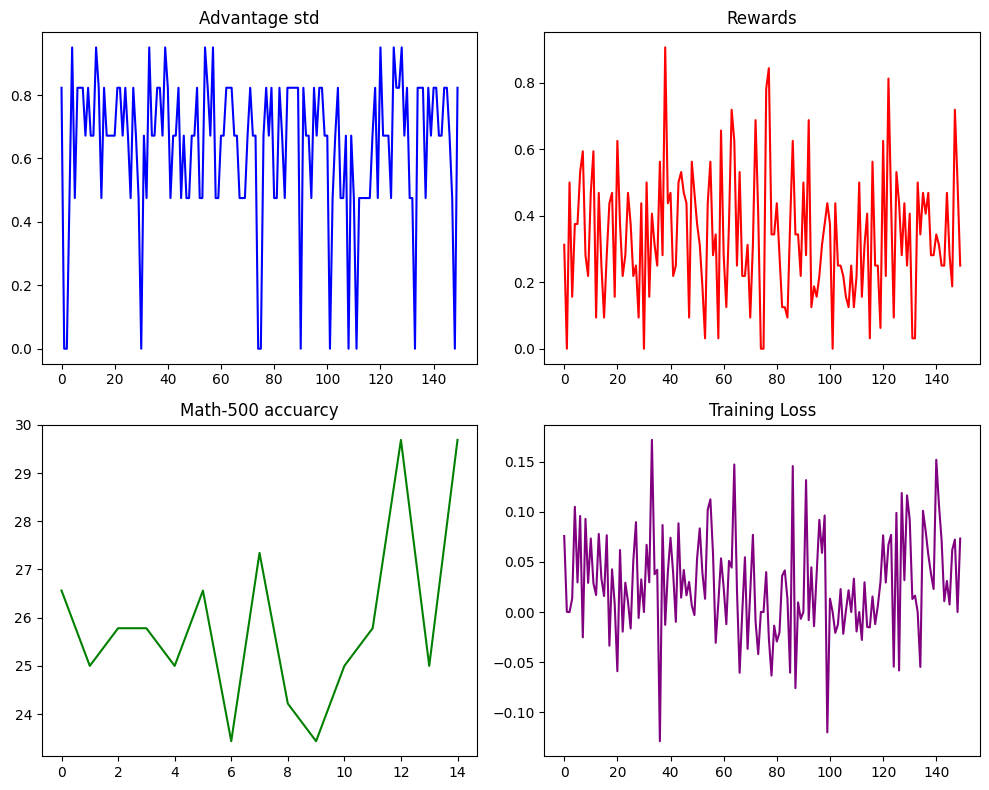

  0%|          | 0/4 [00:23<?, ?it/s]

Think step by step and solve the problem and write the final result on a new line as:
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
To convert the rectangular coordinates \((0, 3)\) to polar coordinates \((r, \theta)\), follow these steps:

### Step 1: Calculate \(r\) (the radial distance)
The formula for \(r\) is:
\[
r = \sqrt{x^2 + y^2}
\]
Substitute \(x = 0\) and \(y = 3\):
\[
r = \sqrt{0^2 + 3^2} = \sqrt{9} = 3
\]

### Step 2: Calculate \(\theta\) (the angle)
The formula for \(\theta\) is:
\[
\theta = \arctan\left(\frac{y}{x}\right)
\]
Substitute \(x = 0\) and \(y = 3\):
\[
\theta = \arctan\left(\frac{3}{0}\right)
\]
Since \(\frac{3}{0}\) is undefined, we need to consider the quadrant in which the point lies.

- If \(x > 0\) and \(y > 0\), \(\theta\) is in the **first quadrant**:
\[
\theta = \arctan(1) = \frac{\pi}{4}
\]
- If \(x < 0\) and \(y > 0\), \(\theta\) is in 

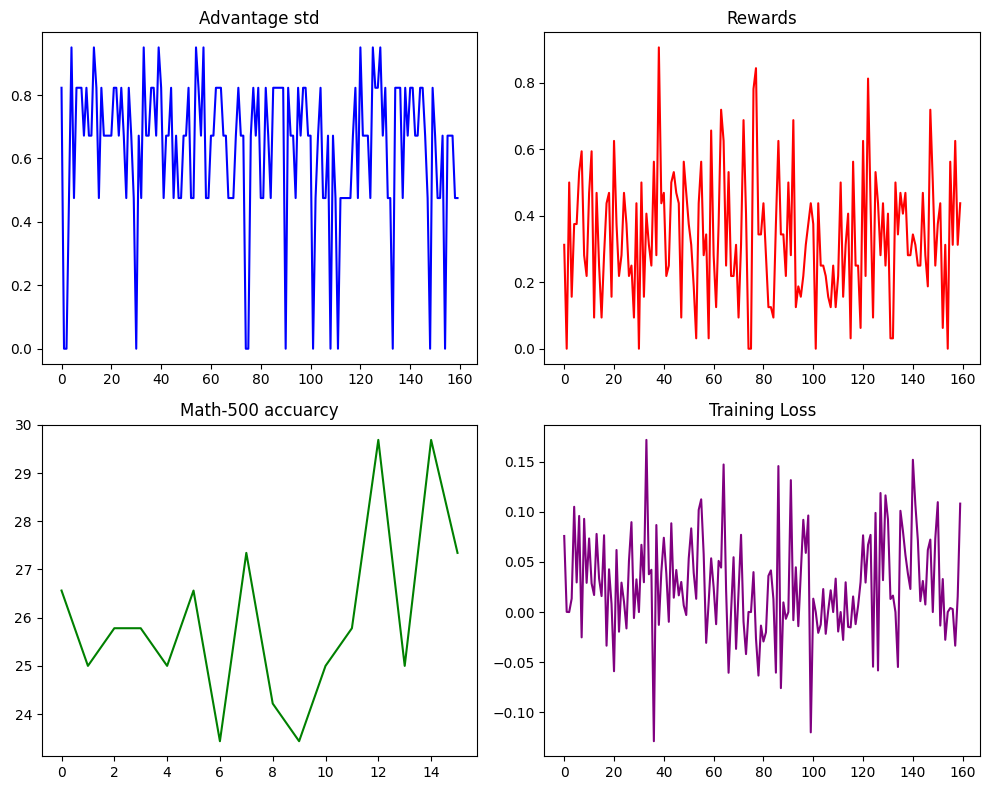

  0%|          | 0/4 [00:23<?, ?it/s]

Think step by step and solve the problem and write the final result on a new line as:
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
To convert the point \((0, 3)\) from rectangular coordinates to polar coordinates, follow these steps:

### Step 1: Recall the formulas to convert from rectangular to polar coordinates
The formulas are:
\[
r = \sqrt{x^2 + y^2}
\]
\[
\theta = \arctan\left(\frac{y}{x}\right)
\]
where:
- \( r \) is the distance from the origin to the point.
- \( \theta \) is the angle (in radians) from the positive \( x \)-axis to the line connecting the origin to the point.

### Step 2: Plug in the values \( x = 0 \) and \( y = 3 \)
\[
r = \sqrt{0^2 + 3^2} = \sqrt{0 + 9} = \sqrt{9} = 3
\]
\[
\theta = \arctan\left(\frac{3}{0}\right)
\]

### Step 3: Evaluate the arctangent
The arctangent of zero is zero:
\[
\arctan\left(\frac{3}{0}\right) = \arctan(\infty)
\]
Sin

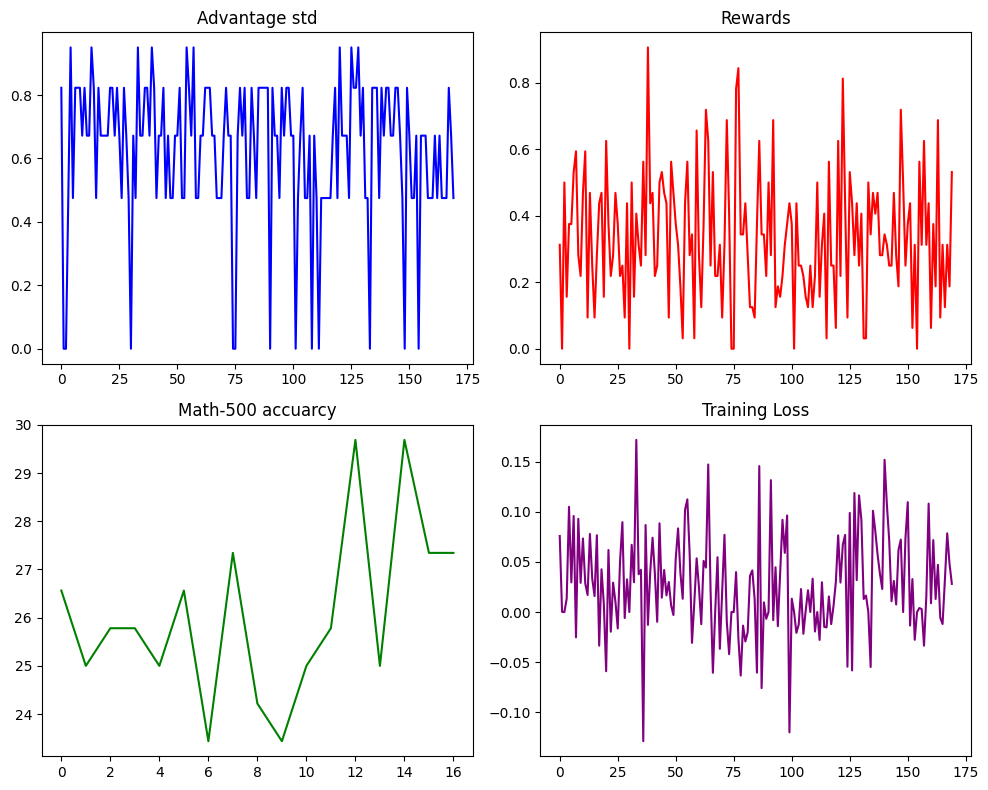

  0%|          | 0/4 [00:23<?, ?it/s]

Think step by step and solve the problem and write the final result on a new line as:
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
To convert the rectangular coordinates \((0, 3)\) to polar coordinates \((r, \theta)\), follow these steps:

1. **Calculate \(r\) (the radial distance):**
   
   The formula for \(r\) is:
   \[
   r = \sqrt{x^2 + y^2}
   \]
   
   Substituting the given values \(x = 0\) and \(y = 3\):
   \[
   r = \sqrt{0^2 + 3^2} = \sqrt{9} = 3
   \]
   
   So, \(r = 3\).

2. **Calculate \(\theta\) (the angle):**
   
   The formula for \(\theta\) is:
   \[
   \theta = \arctan\left(\frac{y}{x}\right)
   \]
   
   Substituting the given values \(x = 0\) and \(y = 3\):
   \[
   \theta = \arctan\left(\frac{3}{0}\right)
   \]
   
   The tangent of an angle is undefined when the \(x\)-coordinate is zero. This means \(\theta\) is either \(\frac{\pi}{2}\) or \(\frac

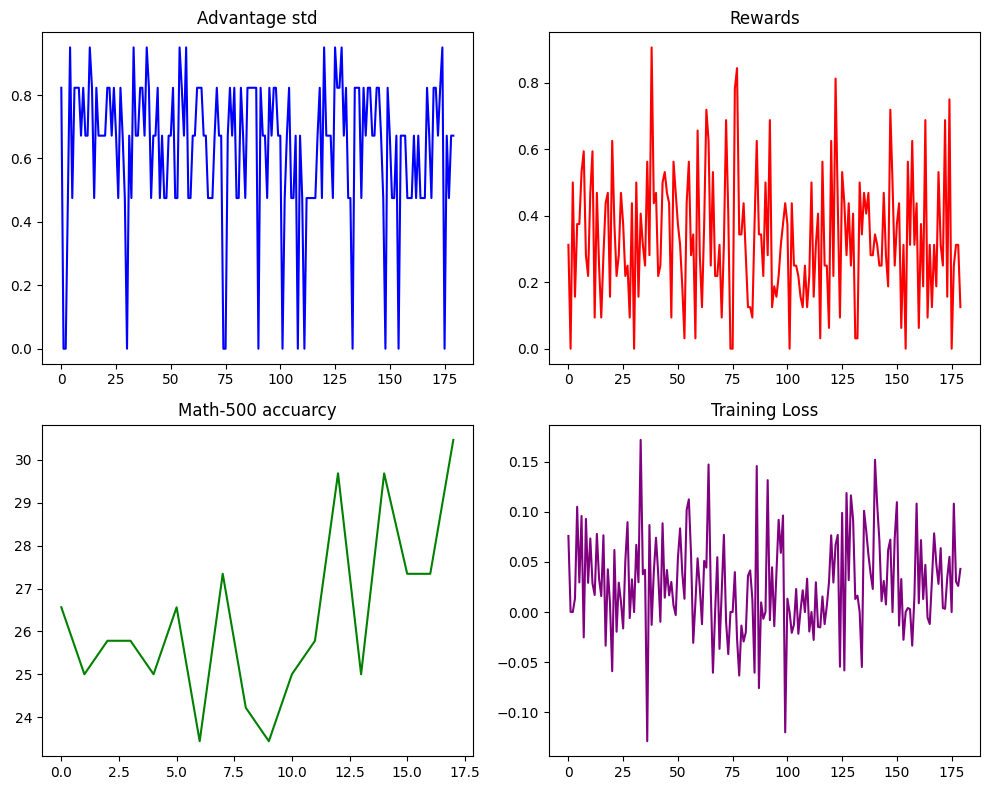

  0%|          | 0/4 [00:00<?, ?it/s]

Think step by step and solve the problem and write the final result on a new line as:
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
To convert the point \((0, 3)\) from rectangular coordinates to polar coordinates, follow these steps:

### Step 1: Recall the formulas
The relationship between rectangular coordinates \((x, y)\) and polar coordinates \((r, \theta)\) is given by:
\[
x = r \cos \theta \quad \text{and} \quad y = r \sin \theta
\]
Additionally, the polar radius \(r\) is:
\[
r = \sqrt{x^2 + y^2}
\]
And the angle \(\theta\) is:
\[
\theta = \arctan\left(\frac{y}{x}\right)
\]

### Step 2: Apply the formulas to the given point
For the point \((0, 3)\):
- \(x = 0\)
- \(y = 3\)

#### Calculate \(r\):
\[
r = \sqrt{x^2 + y^2} = \sqrt{0^2 + 3^2} = \sqrt{0 + 9} = \sqrt{9} = 3
\]
So, \(r = 3\).

#### Calculate \(\theta\):
\[
\theta = \arctan\left(\frac{y}{x}\right) = \arctan

  0%|          | 0/4 [00:23<?, ?it/s]

MATH 500 Accuracy:  21.875 %


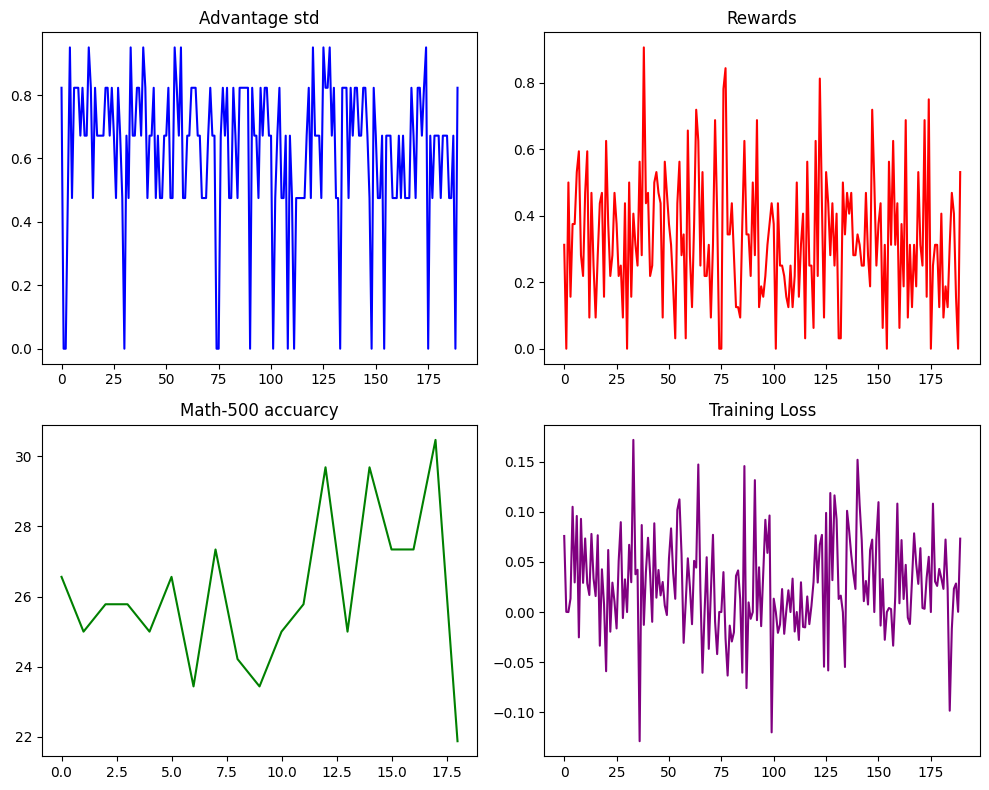

  0%|          | 0/4 [00:23<?, ?it/s]

Think step by step and solve the problem and write the final result on a new line as:
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
To convert the rectangular coordinates \((0, 3)\) to polar coordinates \((r, \theta)\), follow these steps:

### Step 1: Calculate \(r\)
The radial distance \(r\) is calculated using the formula:
\[
r = \sqrt{x^2 + y^2}
\]
Substitute \(x = 0\) and \(y = 3\):
\[
r = \sqrt{0^2 + 3^2} = \sqrt{9} = 3
\]
So, \(r = 3\).

### Step 2: Calculate \(\theta\)
The angle \(\theta\) is calculated using the formula:
\[
\theta = \arctan\left(\frac{y}{x}\right)
\]
Substitute \(x = 0\) and \(y = 3\):
\[
\theta = \arctan\left(\frac{3}{0}\right)
\]
The arctangent of infinity is \(\frac{\pi}{2}\). However, since the point \((0, 3)\) lies on the positive \(y\)-axis, \(\theta\) is already at \(90^\circ\) or \(\frac{\pi}{2}\) radians.

### Final Answer
The polar coor

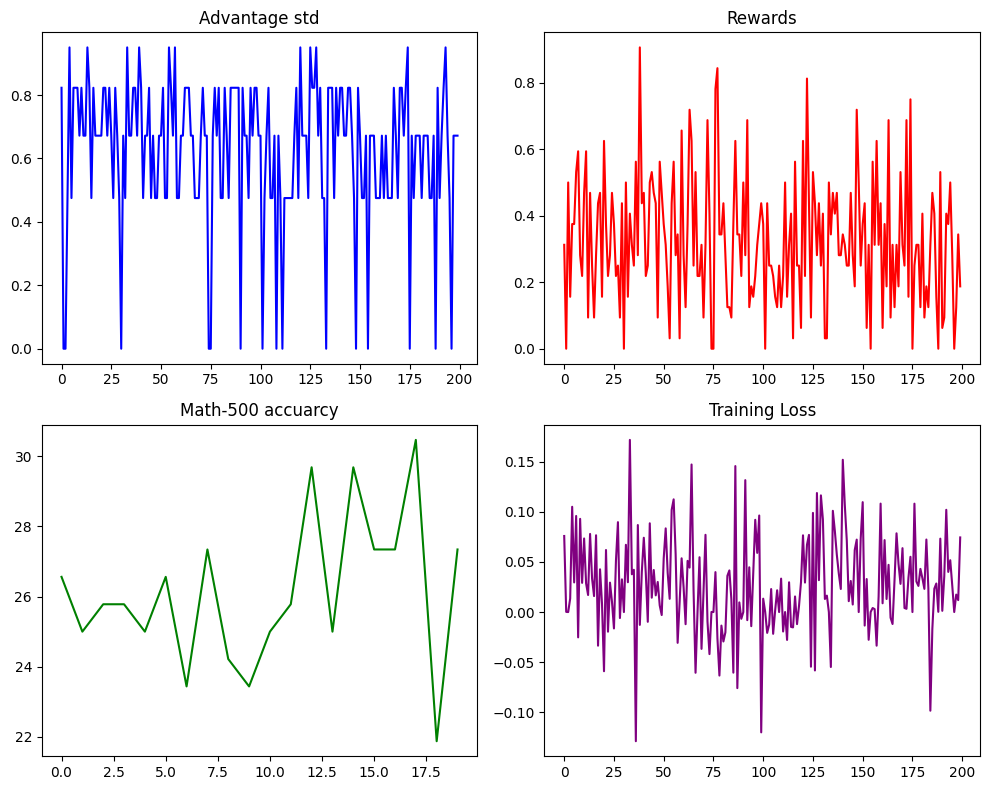

  0%|          | 0/4 [00:23<?, ?it/s]

Think step by step and solve the problem and write the final result on a new line as:
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
To convert the rectangular coordinates \((0, 3)\) to polar coordinates \((r, \theta)\), follow these steps:

1. **Calculate \(r\):**
   
   The radial distance \(r\) is given by the formula:
   \[
   r = \sqrt{x^2 + y^2}
   \]
   
   Substituting \(x = 0\) and \(y = 3\):
   \[
   r = \sqrt{0^2 + 3^2} = \sqrt{9} = 3
   \]

2. **Calculate \(\theta\):**
   
   The angle \(\theta\) is determined by the arctangent of \(\frac{y}{x}\):
   \[
   \theta = \arctan\left(\frac{y}{x}\right)
   \]
   
   Substituting \(x = 0\) and \(y = 3\):
   \[
   \theta = \arctan\left(\frac{3}{0}\right)
   \]
   
   Since \(\frac{3}{0}\) is undefined, we consider the limit as \(x\) approaches 0 from the positive side:
   \[
   \theta = \arctan(+\infty) = \frac{\pi}{2}


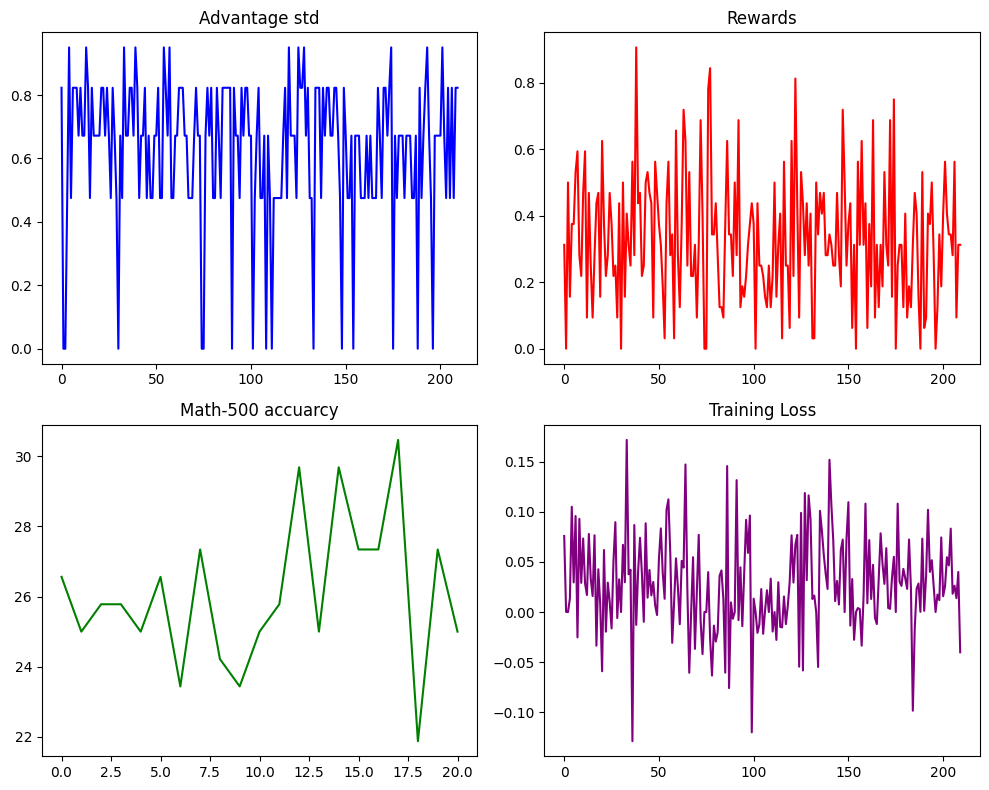

  0%|          | 0/4 [00:23<?, ?it/s]

Think step by step and solve the problem and write the final result on a new line as:
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
To convert the point \((0, 3)\) from rectangular coordinates to polar coordinates, we'll follow these steps:

1. **Calculate \( r \):**
   
   The radius \( r \) is the distance from the origin to the point. It is calculated using the formula:
   \[
   r = \sqrt{x^2 + y^2}
   \]
   
   Substituting the given coordinates \((0, 3)\):
   \[
   r = \sqrt{0^2 + 3^2} = \sqrt{9} = 3
   \]

2. **Calculate \( \theta \):**
   
   The angle \( \theta \) is the angle formed with the positive \( x \)-axis. It is calculated using the formula:
   \[
   \theta = \arctan\left(\frac{y}{x}\right)
   \]
   
   Substituting the given coordinates \((0, 3)\):
   \[
   \theta = \arctan\left(\frac{3}{0}\right)
   \]
   
   Since \( \frac{3}{0} \) is undefined, we nee

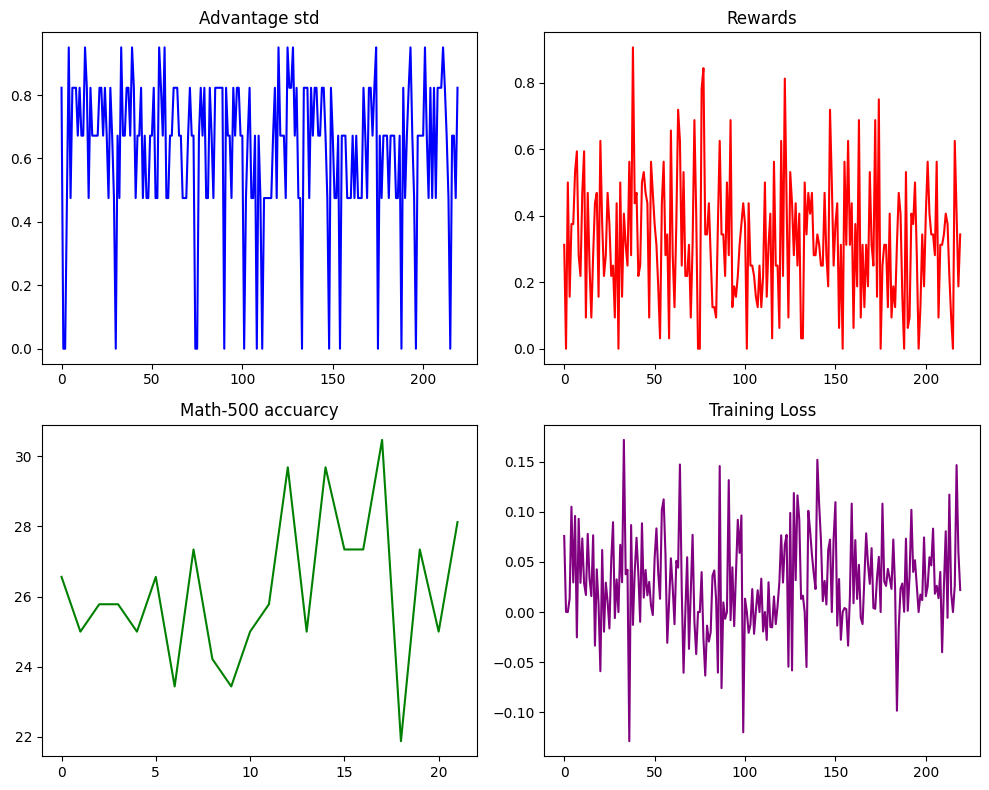

 46%|████▌     | 228/500 [1:14:19<1:28:39, 19.56s/it, dt=1.87e+4, loss=0.0013583586363665745, prompt_lenght=820.90625, tok_per_sec=1749.5684439913036]


KeyboardInterrupt: 

In [ ]:
trainer.train()

In [ ]:
data = [ex for ex in data if len(tokenizer.encode(ex["problem"])) < 700]

In [ ]:
[ex for ex in data if len(tokenizer.encode(ex["problem"])) > 700]

[]

In [ ]:
math_500_accuracy()

  0%|          | 0/4 [00:23<?, ?it/s]

Think step by step and solve the problem and write the final result on a new line as:
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
To convert the point \((0, 3)\) from rectangular coordinates to polar coordinates, we need to determine the radius \(r\) and the angle \(\theta\).

### Step 1: Determine the radius \(r\)
The radius \(r\) is the distance from the origin to the point. It is calculated using the formula:
\[
r = \sqrt{x^2 + y^2}
\]
For the point \((0, 3)\):
\[
r = \sqrt{0^2 + 3^2} = \sqrt{9} = 3
\]

### Step 2: Determine the angle \(\theta\)
The angle \(\theta\) is measured from the positive \(x\)-axis. It can be calculated using the formula:
\[
\theta = \tan^{-1}\left(\frac{y}{x}\right)
\]
However, we need to consider the quadrant in which the point lies.

- **For the point \((0, 3)\):**
  - \(x = 0\) and \(y = 3\).
  - The point lies on the positive \(y\)-axis.

31.25

  0%|          | 1/500 [00:09<1:17:05,  9.27s/it, dt=9.27e+3, loss=0.0, tok_per_sec=2706.8164409620776]

[tensor([0., 0., 0., 0., 0., 0., 0., 0.]), tensor([0., 0., 0., 0., 0., 0., 0., 0.]), tensor([39.2284, 48.1225, 33.7216, 43.1364, 41.3171, 35.7606, 41.9615, 50.3680]), tensor([0., 0., 0., 0., 0., 0., 0., 0.])]


  0%|          | 2/500 [00:18<1:14:49,  9.01s/it, dt=8.84e+3, loss=0.0, tok_per_sec=2839.5560749773185]

[tensor([0., 0., 0., 0., 0., 0., 0., 0.]), tensor([0., 0., 0., 0., 0., 0., 0., 0.]), tensor([20.1919, 19.0038, 13.3604, 11.2957, 16.6716, 18.9272, 11.6037, 12.5448]), tensor([0., 0., 0., 0., 0., 0., 0., 0.])]


  1%|          | 3/500 [00:26<1:14:02,  8.94s/it, dt=8.85e+3, loss=0.0, tok_per_sec=2836.1039175901474]

[tensor([0., 0., 0., 0., 0., 0., 0., 0.]), tensor([0., 0., 0., 0., 0., 0., 0., 0.]), tensor([0., 0., 0., 0., 0., 0., 0., 0.]), tensor([25.0545, 23.3180, 36.9144, 17.8129, 35.0971, 31.2591, 24.6469, 45.2578])]


  1%|          | 3/500 [00:29<1:20:46,  9.75s/it, dt=8.85e+3, loss=0.0, tok_per_sec=2836.1039175901474]


KeyboardInterrupt: 

In [ ]:
numina_math

Dataset({
    features: ['source', 'problem', 'solution', 'messages'],
    num_rows: 12000
})

In [ ]:
for i in range(12000):
  answer = extract_final_candidate(
        numina_math[i]["solution"], fallback=None  # Require \boxed{}
    )
  numina_math[i]["answer"] = answer


In [ ]:
numina_math[0]["answer"] = 0

In [ ]:
https://raw.githubusercontent.com/rasbt/math_full_minus_math500/refs/heads/main/math_full_minus_math500.json

In [ ]:
numina_math = numina_math.map(add_answer)

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

In [ ]:
download_from_github(
    "ch07/03_rlvr_grpo_scripts_advanced/7_4_plus_clip_ratio.py"
)

7_4_plus_clip_ratio.py: 19.1 KB
